# 01 - Exploratory Data Analysis

In this notebook, the dataset is loaded and inspected as a first pass to understand its structure, feature types, and potential data quality issues.

There are a few issues that can complicate downstream analysis and interpretability. The most significant is the presence of `?` categorical values, which appear to indicate missing values, although this is not certain.

## Imports

In [1]:
import sys

from matplotlib import pyplot as plt
import numpy as np
import pandas as pd
import scipy.stats

from IPython.display import display, HTML

sys.path.append("../src")

from my_datasets import census
from my_datasets import dataframe_utils
import ml_utils
from ml_utils import visualizations

## Helper Functions

### `find_group_conflicts`

Identifies rows where the same feature combination in `group_columns` appears with different values in `check_column`.

In [2]:
def find_group_conflicts(
	df,
	group_columns,
	check_column,
	ascending=False,
):
	conflicting_groups = (
		df
		.groupby(group_columns)[check_column]
		.nunique()
		.loc[lambda s: s > 1]
	)

	conflict_rows = df.merge(
		conflicting_groups.reset_index()[group_columns],
		on=group_columns,
		how="inner"
	)

	summary = (
		conflict_rows
		.groupby(group_columns)
		.size()
		.reset_index(name="count")
		.sort_values("count", ascending=ascending)
	)[["count"] + group_columns]

	first_group = summary.iloc[0][group_columns]
	mask = (df[group_columns] == first_group).all(axis=1)
	example_rows = df[mask]

	return summary, conflict_rows, example_rows

## Data Loading and Inspection

The raw dataset is loaded into a dataframe. Basic exploratory inspection is performed to verify that the data has been loaded correctly, including column types, missing values, and general dataset characteristics.

In [3]:
raw_df = census.load_data()

dataframe_utils.describe_df(raw_df)
dataframe_utils.print_dataframe_info(raw_df)

target_column = census.get_target_feature()
weight_column = census.get_sample_weights_feature()

DataFrame Memory Usage: 369.18 MB


,dtype,count,non_null,null_count,unique,top,freq,mean,std,min,25%,50%,75%,max
age,int64,199523,199523,0,NaN,NaN,NaN,34.494199,22.310895,0.0,15.0,33.0,50.0,90.0
class of worker,str,199523,199523,0,9,Not in universe,100245,NaN,NaN,NaN,NaN,NaN,NaN,NaN
detailed industry recode,int64,199523,199523,0,NaN,NaN,NaN,15.35232,18.067129,0.0,0.0,0.0,33.0,51.0
detailed occupation recode,int64,199523,199523,0,NaN,NaN,NaN,11.306556,14.454204,0.0,0.0,0.0,26.0,46.0
education,str,199523,199523,0,17,High school graduate,48407,NaN,NaN,NaN,NaN,NaN,NaN,NaN
wage per hour,int64,199523,199523,0,NaN,NaN,NaN,55.426908,274.896454,0.0,0.0,0.0,0.0,9999.0
enroll in edu inst last wk,str,199523,199523,0,3,Not in universe,186943,NaN,NaN,NaN,NaN,NaN,NaN,NaN
marital stat,str,199523,199523,0,7,Never married,86485,NaN,NaN,NaN,NaN,NaN,NaN,NaN
major industry code,str,199523,199523,0,24,Not in universe or children,100684,NaN,NaN,NaN,NaN,NaN,NaN,NaN
major occupation code,str,199523,199523,0,15,Not in universe,100684,NaN,NaN,NaN,NaN,NaN,NaN,NaN


,age,class of worker,detailed industry recode,detailed occupation recode,education,wage per hour,enroll in edu inst last wk,marital stat,major industry code,major occupation code,race,hispanic origin,sex,member of a labor union,reason for unemployment,full or part time employment stat,capital gains,capital losses,dividends from stocks,tax filer stat,region of previous residence,state of previous residence,detailed household and family stat,detailed household summary in household,weight,migration code-change in msa,migration code-change in reg,migration code-move within reg,live in this house 1 year ago,migration prev res in sunbelt,num persons worked for employer,family members under 18,country of birth father,country of birth mother,country of birth self,citizenship,own business or self employed,fill inc questionnaire for veteran's admin,veterans benefits,weeks worked in year,year,label
0,73,Not in universe,0,0,High school graduate,0,Not in universe,Widowed,Not in universe or children,Not in universe,White,All other,Female,Not in universe,Not in universe,Not in labor force,0,0,0,Nonfiler,Not in universe,Not in universe,Other Rel 18+ ever marr not in subfamily,Other relative of householder,1700.09,?,?,?,Not in universe under 1 year old,?,0,Not in universe,United-States,United-States,United-States,Native- Born in the United States,0,Not in universe,2,0,95,- 50000.
1,58,Self-employed-not incorporated,4,34,Some college but no degree,0,Not in universe,Divorced,Construction,Precision production craft & repair,White,All other,Male,Not in universe,Not in universe,Children or Armed Forces,0,0,0,Head of household,South,Arkansas,Householder,Householder,1053.55,MSA to MSA,Same county,Same county,No,Yes,1,Not in universe,United-States,United-States,United-States,Native- Born in the United States,0,Not in universe,2,52,94,- 50000.
2,18,Not in universe,0,0,10th grade,0,High school,Never married,Not in universe or children,Not in universe,Asian or Pacific Islander,All other,Female,Not in universe,Not in universe,Not in labor force,0,0,0,Nonfiler,Not in universe,Not in universe,Child 18+ never marr Not in a subfamily,Child 18 or older,991.95,?,?,?,Not in universe under 1 year old,?,0,Not in universe,Vietnam,Vietnam,Vietnam,Foreign born- Not a citizen of U S,0,Not in universe,2,0,95,- 50000.
3,9,Not in universe,0,0,Children,0,Not in universe,Never married,Not in universe or children,Not in universe,White,All other,Female,Not in universe,Not in universe,Children or Armed Forces,0,0,0,Nonfiler,Not in universe,Not in universe,Child <18 never marr not in subfamily,Child under 18 never married,1758.14,Nonmover,Nonmover,Nonmover,Yes,Not in universe,0,Both parents present,United-States,United-States,United-States,Native- Born in the United States,0,Not in universe,0,0,94,- 50000.
4,10,Not in universe,0,0,Children,0,Not in universe,Never married,Not in universe or children,Not in universe,White,All other,Female,Not in universe,Not in universe,Children or Armed Forces,0,0,0,Nonfiler,Not in universe,Not in universe,Child <18 never marr not in subfamily,Child under 18 never married,1069.16,Nonmover,Nonmover,Nonmover,Yes,Not in universe,0,Both parents present,United-States,United-States,United-States,Native- Born in the United States,0,Not in universe,0,0,94,- 50000.
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
199518,87,Not in universe,0,0,7th and 8th grade,0,Not in universe,Married-civilian spouse present,Not in universe or children,Not in universe,White,All other,Male,Not in universe,Not in universe,Not in labor force,0,0,0,Joint both 65+,Not in universe,Not in universe,Householder,Householder,955.27,?,?,?,Not in universe under 1 year old,?,0,Not in universe,Canada,United-States,United-States,Native- Born in the United States,0,Not in universe,2,0,95,- 50000.
199519,65,Self-employed-incorporated,37,2,11th grade,0,Not in univers

## Missing Data

### Missing Values

The dataset contains true missing values only in the `hispanic origin` feature. This is notable because the number of missing values is small and there are no corresponding “Not in universe” entries for this field, nor an explicit category indicating a non-Hispanic or not applicable response. See below for further details on the `hispanic origin` feature.

Several other features also contain categorical values of `?`, which are likely used as placeholders for missing or unknown values and should be treated as such during preprocessing.

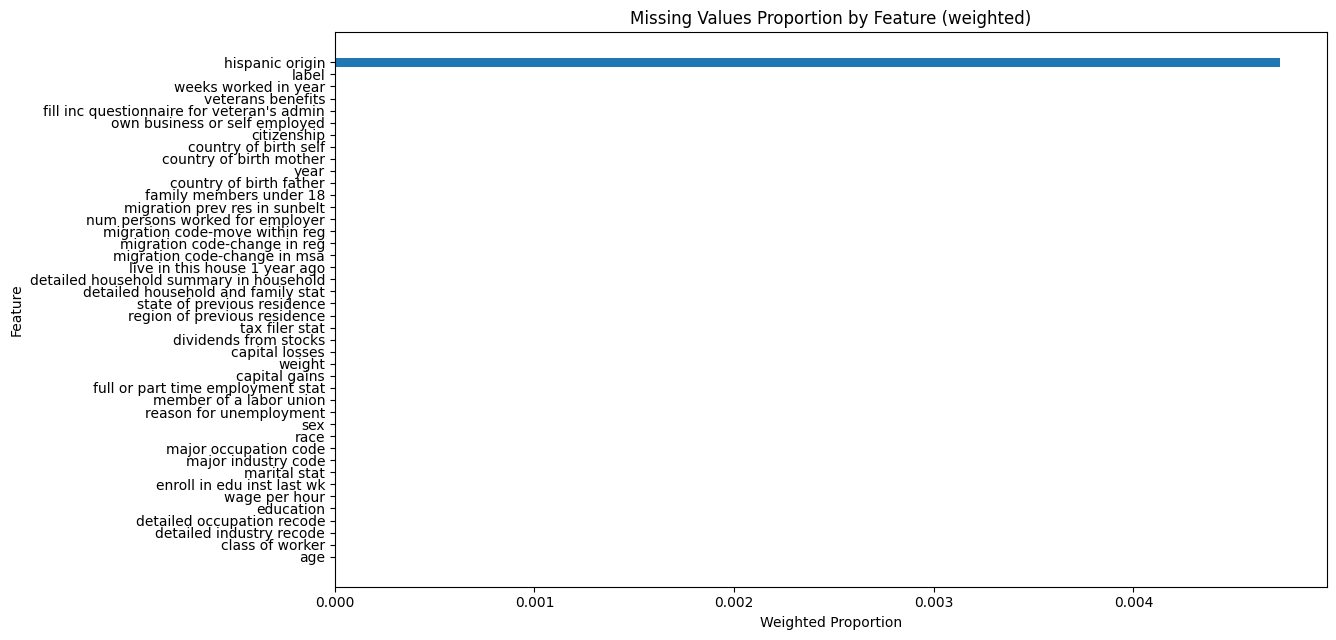

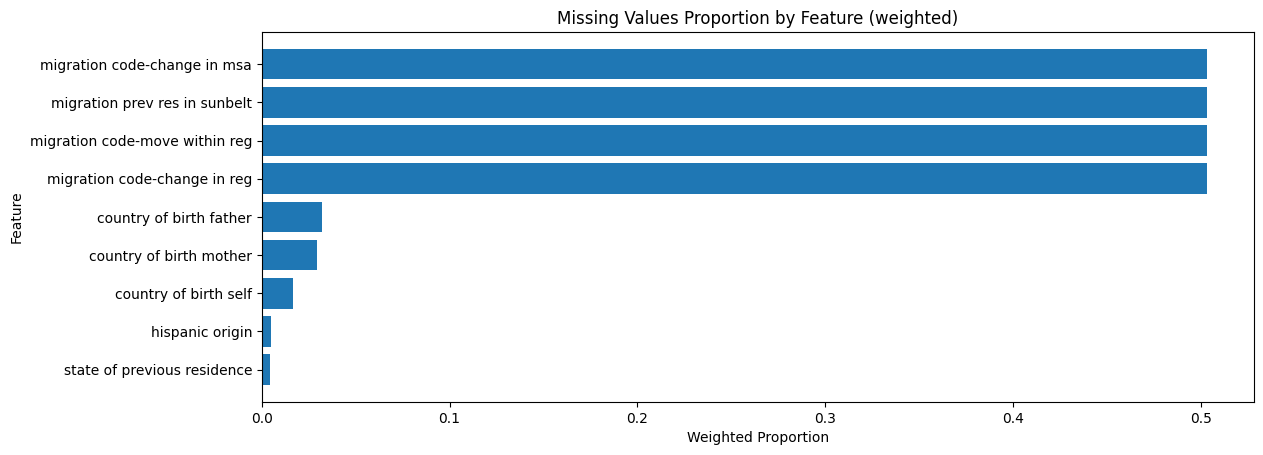

2026-06-18 00:51:02,988 - INFO - Saved DataFrame to results directory: /Users/jagraves21/notebooks/jpm/census-income-ml-project/data/Census/results/missing_values.csv


,Feature,Percentage (%)
0,migration code-change in msa,50.303059
1,migration code-move within reg,50.303059
2,migration prev res in sunbelt,50.303059
3,migration code-change in reg,50.303059
4,country of birth father,3.220037
5,country of birth mother,2.937707
6,country of birth self,1.649415
7,hispanic origin,0.473162
8,state of previous residence,0.453129


2026-06-18 00:51:03,085 - INFO - Saved figure to figures directory: /Users/jagraves21/notebooks/jpm/census-income-ml-project/data/Census/figures/missing_values.png


In [4]:
display(HTML("<h4>Considering '?' as a Valid Category</h4>"))
visualizations.plot_missing_values(
    raw_df,
    weight_column=weight_column,
    figsize=(2*6.4, 1.5*4.8)
)

display(HTML("<h4>Considering '?' as a Missing Value</h4>"))
missing_df,fig,ax = visualizations.plot_missing_values(
    raw_df.replace("?", np.nan),
    only_missing=True,
    weight_column=weight_column,
    figsize=(2*6.4, 4.8),
    return_fig=True
)
plt.show()
census.save_results_dataframe(missing_df, "missing_values.csv")

display(missing_df)
_ = census.save_figure(fig, "missing_values.png")

### Not in Universe (NIU) Values

The dataset contains `Not in universe` responses. This indicates that a question was not applicable to certain respondents, possibly due to survey skip logic. These values should not be treated as missing data, as they reflect structural absence rather than non-response.

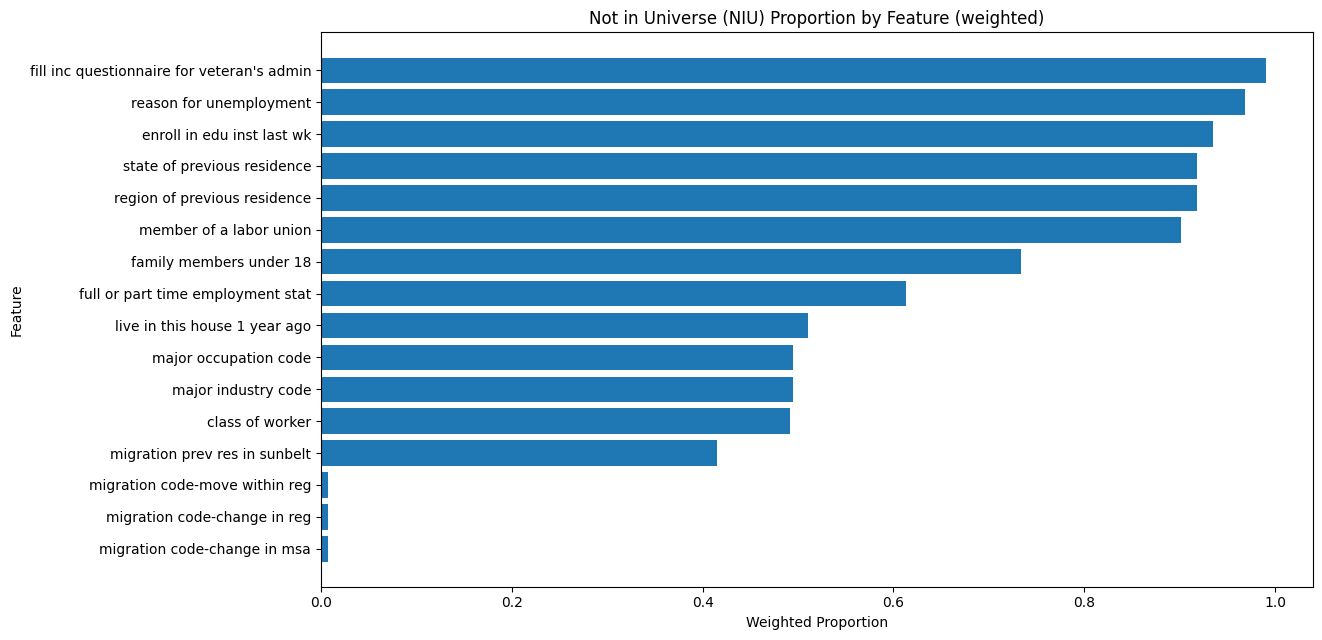

2026-06-18 00:51:03,774 - INFO - Saved figure to figures directory: /Users/jagraves21/notebooks/jpm/census-income-ml-project/data/Census/figures/niu.png


,Feature,NIU Indicator Value,Percentage (%)
0,fill inc questionnaire for veteran's admin,Not in universe,98.998453
1,reason for unemployment,Not in universe,96.793541
2,enroll in edu inst last wk,Not in universe,93.450788
3,region of previous residence,Not in universe,91.757424
4,state of previous residence,Not in universe,91.757424
5,member of a labor union,Not in universe,90.095237
6,family members under 18,Not in universe,73.356976
7,full or part time employment stat,Children or Armed Forces,61.313034
8,live in this house 1 year ago,Not in universe under 1 year old,51.07217
9,major industry code,Not in universe or children,49.439915


2026-06-18 00:51:03,782 - INFO - Saved DataFrame to results directory: /Users/jagraves21/notebooks/jpm/census-income-ml-project/data/Census/results/niu.csv


In [5]:
niu_df,fig,ax = visualizations.plot_not_in_universe(
    raw_df,
    niu_only=True,
    weight_column=weight_column,
    figsize=(2*6.4, 1.5*4.8),
    return_fig=True
)
plt.show()
census.save_figure(fig, "niu.png")

display(niu_df)
_ = census.save_results_dataframe(niu_df, "niu.csv")

## Duplicates

### Full Duplicates

The dataset contains records that are identical across all fields, including `weight`. This may indicate true duplicate entries rather than distinct sampling contributions. These should be reviewed, as they may reflect data duplication during collection or processing and could inflate counts if not handled properly.

In [6]:
# row level duplicates
total_duplicate_rows = raw_df.duplicated(keep="first").sum()
duplicate_row_percentage = (total_duplicate_rows / len(raw_df)) * 100

# pattern level duplicates
duplicates_df = (
	raw_df
	.value_counts()
	.rename("count")
	.reset_index()
)

duplicates_df = duplicates_df[duplicates_df["count"] > 1]
duplicates_df = duplicates_df.sort_values("count", ascending=False)

print(f"Total duplicate rows (excluding first occurrences): {total_duplicate_rows}")
print(f"Percentage of duplicate rows: {duplicate_row_percentage:.2f}%")
print(f"Number of duplicate row patterns: {len(duplicates_df)}")

with pd.option_context("display.max_rows", 10, "display.max_columns", None):
	display(duplicates_df)

Total duplicate rows (excluding first occurrences): 3229
Percentage of duplicate rows: 1.62%
Number of duplicate row patterns: 2762


,age,class of worker,detailed industry recode,detailed occupation recode,education,wage per hour,enroll in edu inst last wk,marital stat,major industry code,major occupation code,race,hispanic origin,sex,member of a labor union,reason for unemployment,full or part time employment stat,capital gains,capital losses,dividends from stocks,tax filer stat,region of previous residence,state of previous residence,detailed household and family stat,detailed household summary in household,weight,migration code-change in msa,migration code-change in reg,migration code-move within reg,live in this house 1 year ago,migration prev res in sunbelt,num persons worked for employer,family members under 18,country of birth father,country of birth mother,country of birth self,citizenship,own business or self employed,fill inc questionnaire for veteran's admin,veterans benefits,weeks worked in year,year,label,count
0,11,Not in universe,0,0,Children,0,Not in universe,Never married,Not in universe or children,Not in universe,White,All other,Female,Not in universe,Not in universe,Children or Armed Forces,0,0,0,Nonfiler,Not in universe,Not in universe,Child <18 never marr not in subfamily,Child under 18 never married,1131.62,Nonmover,Nonmover,Nonmover,Yes,Not in universe,0,Both parents present,United-States,United-States,United-States,Native- Born in the United States,0,Not in universe,0,0,94,- 50000.,6
1,3,Not in universe,0,0,Children,0,Not in universe,Never married,Not in universe or children,Not in universe,White,All other,Female,Not in universe,Not in universe,Children or Armed Forces,0,0,0,Nonfiler,Not in universe,Not in universe,Child <18 never marr not in subfamily,Child under 18 never married,2125.99,?,?,?,Not in universe under 1 year old,?,0,Both parents present,United-States,United-States,United-States,Native- Born in the United States,0,Not in universe,0,0,95,- 50000.,6
2,13,Not in universe,0,0,Children,0,Not in universe,Never married,Not in universe or children,Not in universe,White,All other,Male,Not in universe,Not in universe,Children or Armed Forces,0,0,0,Nonfiler,Not in universe,Not in universe,Child <18 never marr not in subfamily,Child under 18 never married,981.79,Nonmover,Nonmover,Nonmover,Yes,Not in universe,0,Both parents present,United-States,United-States,United-States,Native- Born in the United States,0,Not in universe,0,0,94,- 50000.,5
3,3,Not in universe,0,0,Children,0,Not in universe,Never married,Not in universe or children,Not in universe,White,All other,Male,Not in universe,Not in universe,Children or Armed Forces,0,0,0,Nonfiler,Not in universe,Not in universe,Child <18 never marr not in subfamily,Child under 18 never married,966.31,?,?,?,Not in universe under 1 year old,?,0,Both parents present,United-States,United-States,United-States,Native- Born in the United States,0,Not in universe,0,0,95,- 50000.,5
4,8,Not in universe,0,0,Children,0,Not in universe,Never married,Not in universe or children,Not in universe,White,All other,Female,Not in universe,Not in universe,Children or Armed Forces,0,0,0,Nonfiler,Not in universe,Not in universe,Child <18 never marr not in subfamily,Child under 18 never married,1979.97,?,?,?,Not in universe under 1 year old,?,0,Both parents present,United-States,United-States,United-States,Native- Born in the United States,0,Not in universe,0,0,95,- 50000.,5
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
2757,12,Not in universe,0,0,Children,0,Not in universe,Never married,Not in universe or children,Not in universe,White,All other,Female,Not in universe,Not in universe,Children or Armed Forces,0,0,0,Nonfiler,Not in universe,Not in universe,Child <18 never marr not in subfamily,Child under 18 never married,1202.24,?,?,?,Not in universe under 1 year old,?,0,Both parents present,United-States,United-States,United-States,Native- Born in the United States,0,Not in universe,0

### Partial Duplicates

The dataset contains records that are identical across all fields except for `weight`. This likely reflects the same observation being assigned multiple weight contributions, for example due to stratified sampling or weight calibration.

In [7]:
group_columns = [
	column
	for column in raw_df.columns
	if column != weight_column
]

summary_df, conflict_rows, example_rows = find_group_conflicts(
	df=raw_df,
	group_columns=group_columns,
	check_column=weight_column
)

num_conflict_patterns = len(summary_df)
num_conflict_rows = len(conflict_rows)
num_extra_rows = num_conflict_rows - num_conflict_patterns

print(f"Partial duplicate rows (excluding first occurrences): {num_extra_rows}")
print(f"Number of partial duplicate patterns: {num_conflict_patterns}")
print(f"Percentage of partial duplicate patterns: {(num_conflict_patterns / len(raw_df)) * 100:.2f}%")

with pd.option_context("display.max_rows", 5, "display.max_columns", None):
	display(HTML("<h3>Partial Duplicates</h3>"))
	display(summary_df)
	display(HTML("<h3>Example Problem Group</h3>"))
	display(example_rows.head())

Partial duplicate rows (excluding first occurrences): 46493
Number of partial duplicate patterns: 6992
Percentage of partial duplicate patterns: 3.50%


,count,age,class of worker,detailed industry recode,detailed occupation recode,education,wage per hour,enroll in edu inst last wk,marital stat,major industry code,major occupation code,race,hispanic origin,sex,member of a labor union,reason for unemployment,full or part time employment stat,capital gains,capital losses,dividends from stocks,tax filer stat,region of previous residence,state of previous residence,detailed household and family stat,detailed household summary in household,migration code-change in msa,migration code-change in reg,migration code-move within reg,live in this house 1 year ago,migration prev res in sunbelt,num persons worked for employer,family members under 18,country of birth father,country of birth mother,country of birth self,citizenship,own business or self employed,fill inc questionnaire for veteran's admin,veterans benefits,weeks worked in year,year,label
2306,414,11,Not in universe,0,0,Children,0,Not in universe,Never married,Not in universe or children,Not in universe,White,All other,Male,Not in universe,Not in universe,Children or Armed Forces,0,0,0,Nonfiler,Not in universe,Not in universe,Child <18 never marr not in subfamily,Child under 18 never married,?,?,?,Not in universe under 1 year old,?,0,Both parents present,United-States,United-States,United-States,Native- Born in the United States,0,Not in universe,0,0,95,- 50000.
1952,414,9,Not in universe,0,0,Children,0,Not in universe,Never married,Not in universe or children,Not in universe,White,All other,Male,Not in universe,Not in universe,Children or Armed Forces,0,0,0,Nonfiler,Not in universe,Not in universe,Child <18 never marr not in subfamily,Child under 18 never married,?,?,?,Not in universe under 1 year old,?,0,Both parents present,United-States,United-States,United-States,Native- Born in the United States,0,Not in universe,0,0,95,- 50000.
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
6989,2,90,Not in universe,0,0,Some college but no degree,0,Not in universe,Widowed,Not in universe or children,Not in universe,White,All other,Female,Not in universe,Not in universe,Not in labor force,0,0,0,Nonfiler,Not in universe,Not in universe,Other Rel 18+ ever marr not in subfamily,Other relative of householder,?,?,?,Not in universe under 1 year old,?,0,Not in universe,United-States,United-States,United-States,Native- Born in the United States,0,Not in universe,2,0,95,- 50000.
6990,2,90,Not in universe,0,0,Some college but no degree,0,Not in universe,Widowed,Not in universe or children,Not in universe,White,All other,Female,Not in universe,Not in universe,Not in labor force,0,0,0,Single,Not in universe,Not in universe,Nonfamily householder,Householder,?,?,?,Not in universe under 1 year old,?,0,Not in universe,United-States,United-States,United-States,Native- Born in the United States,0,Not in universe,2,0,95,- 50000.


,age,class of worker,detailed industry recode,detailed occupation recode,education,wage per hour,enroll in edu inst last wk,marital stat,major industry code,major occupation code,race,hispanic origin,sex,member of a labor union,reason for unemployment,full or part time employment stat,capital gains,capital losses,dividends from stocks,tax filer stat,region of previous residence,state of previous residence,detailed household and family stat,detailed household summary in household,weight,migration code-change in msa,migration code-change in reg,migration code-move within reg,live in this house 1 year ago,migration prev res in sunbelt,num persons worked for employer,family members under 18,country of birth father,country of birth mother,country of birth self,citizenship,own business or self employed,fill inc questionnaire for veteran's admin,veterans benefits,weeks worked in year,year,label
288,11,Not in universe,0,0,Children,0,Not in universe,Never married,Not in universe or children,Not in universe,White,All other,Male,Not in universe,Not in universe,Children or Armed Forces,0,0,0,Nonfiler,Not in universe,Not in universe,Child <18 never marr not in subfamily,Child under 18 never married,7066.72,?,?,?,Not in universe under 1 year old,?,0,Both parents present,United-States,United-States,United-States,Native- Born in the United States,0,Not in universe,0,0,95,- 50000.
482,11,Not in universe,0,0,Children,0,Not in universe,Never married,Not in universe or children,Not in universe,White,All other,Male,Not in universe,Not in universe,Children or Armed Forces,0,0,0,Nonfiler,Not in universe,Not in universe,Child <18 never marr not in subfamily,Child under 18 never married,1249.97,?,?,?,Not in universe under 1 year old,?,0,Both parents present,United-States,United-States,United-States,Native- Born in the United States,0,Not in universe,0,0,95,- 50000.
778,11,Not in universe,0,0,Children,0,Not in universe,Never married,Not in universe or children,Not in universe,White,All other,Male,Not in universe,Not in universe,Children or Armed Forces,0,0,0,Nonfiler,Not in universe,Not in universe,Child <18 never marr not in subfamily,Child under 18 never married,1278.35,?,?,?,Not in universe under 1 year old,?,0,Both parents present,United-States,United-States,United-States,Native- Born in the United States,0,Not in universe,0,0,95,- 50000.
1435,11,Not in universe,0,0,Children,0,Not in universe,Never married,Not in universe or children,Not in universe,White,All other,Male,Not in universe,Not in universe,Children or Armed Forces,0,0,0,Nonfiler,Not in universe,Not in universe,Child <18 never marr not in subfamily,Child under 18 never married,2981.64,?,?,?,Not in universe under 1 year old,?,0,Both parents present,United-States,United-States,United-States,Native- Born in the United States,0,Not in universe,0,0,95,- 50000.
2356,11,Not in universe,0,0,Children,0,Not in universe,Never married,Not in universe or children,Not in universe,White,All other,Male,Not in universe,Not in universe,Children or Armed Forces,0,0,0,Nonfiler,Not in universe,Not in universe,Child <18 never marr not in subfamily,Child under 18 never married,1418.43,?,?,?,Not in universe under 1 year old,?,0,Both parents present,United-States,United-States,United-States,Native- Born in the United States,0,Not in universe,0,0,95,- 50000.


## Label Conflicts

The dataset contains records that share identical feature values (excluding `weight`) but have different target labels. This is not necessarily a data error. Instead, it indicates that the feature space may not fully separate the target class, or that there is inherent ambiguity or uncertainty in the target class.

In this dataset, the weighted share of observations involved in target label conflicts is approximately 0.19%. This indicates that only a small fraction of the population mass is affected. This suggests that the target is largely well-defined and nearly deterministic with respect to the features. These conflicts are unlikely to impose a meaningful impact on model performance.

In [8]:
group_columns = [
	column
	for column in raw_df.columns
	if column not in (target_column, weight_column)
]

summary_df, conflict_rows, example_rows = find_group_conflicts(
	df=raw_df,
	group_columns=group_columns,
	check_column=target_column
)

weighted_summary = (
	conflict_rows
	.groupby(group_columns)
	.agg(
		count=(target_column, "size"),
		total_weight=(weight_column, "sum"),
		n_labels=(target_column, "nunique")
	)
	.sort_values("total_weight", ascending=False)
	.reset_index()
)

total_weight = raw_df[weight_column].sum()
unweighted_share = len(conflict_rows) / len(raw_df)

print(f"Rows involved in label conflicts: {len(conflict_rows)}")
print(f"Number of conflicting feature patterns: {len(summary_df)}")
print(f"Unweighted share of data in conflicts: {unweighted_share:.2%}")
print(f"Weighted share of data in conflicts: {weighted_summary['total_weight'].sum() / total_weight:.2%}")

with pd.option_context("display.max_rows", 5, "display.max_columns", None):
	display(HTML("<h3>Label Conflicts</h3>"))
	display(summary_df)
	display(HTML("<h3>Example Label Conflicts</h3>"))
	display(example_rows.head())

Rows involved in label conflicts: 379
Number of conflicting feature patterns: 89
Unweighted share of data in conflicts: 0.19%
Weighted share of data in conflicts: 0.19%


,count,age,class of worker,detailed industry recode,detailed occupation recode,education,wage per hour,enroll in edu inst last wk,marital stat,major industry code,major occupation code,race,hispanic origin,sex,member of a labor union,reason for unemployment,full or part time employment stat,capital gains,capital losses,dividends from stocks,tax filer stat,region of previous residence,state of previous residence,detailed household and family stat,detailed household summary in household,migration code-change in msa,migration code-change in reg,migration code-move within reg,live in this house 1 year ago,migration prev res in sunbelt,num persons worked for employer,family members under 18,country of birth father,country of birth mother,country of birth self,citizenship,own business or self employed,fill inc questionnaire for veteran's admin,veterans benefits,weeks worked in year,year
50,24,68,Not in universe,0,0,High school graduate,0,Not in universe,Married-civilian spouse present,Not in universe or children,Not in universe,White,All other,Female,Not in universe,Not in universe,Not in labor force,0,0,0,Joint both 65+,Not in universe,Not in universe,Spouse of householder,Spouse of householder,?,?,?,Not in universe under 1 year old,?,0,Not in universe,United-States,United-States,United-States,Native- Born in the United States,0,Not in universe,2,0,95
75,18,76,Not in universe,0,0,High school graduate,0,Not in universe,Married-civilian spouse present,Not in universe or children,Not in universe,White,All other,Female,Not in universe,Not in universe,Children or Armed Forces,0,0,0,Joint both 65+,Not in universe,Not in universe,Spouse of householder,Spouse of householder,Nonmover,Nonmover,Nonmover,Yes,Not in universe,0,Not in universe,United-States,United-States,United-States,Native- Born in the United States,0,Not in universe,2,0,94
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
84,2,82,Not in universe,0,0,Bachelors degree(BA AB BS),0,Not in universe,Widowed,Not in universe or children,Not in universe,White,All other,Female,Not in universe,Not in universe,Children or Armed Forces,0,0,0,Single,Not in universe,Not in universe,Nonfamily householder,Householder,Nonmover,Nonmover,Nonmover,Yes,Not in universe,0,Not in universe,United-States,United-States,United-States,Native- Born in the United States,0,Not in universe,2,0,94
87,2,85,Not in universe,0,0,Masters degree(MA MS MEng MEd MSW MBA),0,Not in universe,Widowed,Not in universe or children,Not in universe,White,All other,Male,Not in universe,Not in universe,Not in labor force,0,0,0,Single,Not in universe,Not in universe,Nonfamily householder,Householder,?,?,?,Not in universe under 1 year old,?,0,Not in universe,United-States,United-States,United-States,Native- Born in the United States,0,Not in universe,2,0,95


,age,class of worker,detailed industry recode,detailed occupation recode,education,wage per hour,enroll in edu inst last wk,marital stat,major industry code,major occupation code,race,hispanic origin,sex,member of a labor union,reason for unemployment,full or part time employment stat,capital gains,capital losses,dividends from stocks,tax filer stat,region of previous residence,state of previous residence,detailed household and family stat,detailed household summary in household,weight,migration code-change in msa,migration code-change in reg,migration code-move within reg,live in this house 1 year ago,migration prev res in sunbelt,num persons worked for employer,family members under 18,country of birth father,country of birth mother,country of birth self,citizenship,own business or self employed,fill inc questionnaire for veteran's admin,veterans benefits,weeks worked in year,year,label
3949,68,Not in universe,0,0,High school graduate,0,Not in universe,Married-civilian spouse present,Not in universe or children,Not in universe,White,All other,Female,Not in universe,Not in universe,Not in labor force,0,0,0,Joint both 65+,Not in universe,Not in universe,Spouse of householder,Spouse of householder,1036.27,?,?,?,Not in universe under 1 year old,?,0,Not in universe,United-States,United-States,United-States,Native- Born in the United States,0,Not in universe,2,0,95,50000+.
10276,68,Not in universe,0,0,High school graduate,0,Not in universe,Married-civilian spouse present,Not in universe or children,Not in universe,White,All other,Female,Not in universe,Not in universe,Not in labor force,0,0,0,Joint both 65+,Not in universe,Not in universe,Spouse of householder,Spouse of householder,5500.38,?,?,?,Not in universe under 1 year old,?,0,Not in universe,United-States,United-States,United-States,Native- Born in the United States,0,Not in universe,2,0,95,- 50000.
19926,68,Not in universe,0,0,High school graduate,0,Not in universe,Married-civilian spouse present,Not in universe or children,Not in universe,White,All other,Female,Not in universe,Not in universe,Not in labor force,0,0,0,Joint both 65+,Not in universe,Not in universe,Spouse of householder,Spouse of householder,1186.78,?,?,?,Not in universe under 1 year old,?,0,Not in universe,United-States,United-States,United-States,Native- Born in the United States,0,Not in universe,2,0,95,- 50000.
21873,68,Not in universe,0,0,High school graduate,0,Not in universe,Married-civilian spouse present,Not in universe or children,Not in universe,White,All other,Female,Not in universe,Not in universe,Not in labor force,0,0,0,Joint both 65+,Not in universe,Not in universe,Spouse of householder,Spouse of householder,1036.27,?,?,?,Not in universe under 1 year old,?,0,Not in universe,United-States,United-States,United-States,Native- Born in the United States,0,Not in universe,2,0,95,- 50000.
28242,68,Not in universe,0,0,High school graduate,0,Not in universe,Married-civilian spouse present,Not in universe or children,Not in universe,White,All other,Female,Not in universe,Not in universe,Not in labor force,0,0,0,Joint both 65+,Not in universe,Not in universe,Spouse of householder,Spouse of householder,893.05,?,?,?,Not in universe under 1 year old,?,0,Not in universe,United-States,United-States,United-States,Native- Born in the United States,0,Not in universe,2,0,95,- 50000.


## Variable Association

### Numeric Relationships

A correlation heatmap based on the Pearson correlation coefficient is used to examine relationships between numeric features in the dataset. The target feature is converted to a binary numeric feature to ensure it is included in the correlation analysis. The sample weight column is incorporated into the computation so that the measured associations better reflect the weighted population represented by the data.

A relatively strong positive correlation is observed between `weeks worked in a year` and `num persons worked for employer`. There also appears to be a notable correlation between `veterans benefits` and `age`, as well as a weaker correlation between `veterans benefits` and `num persons worked for employer`.

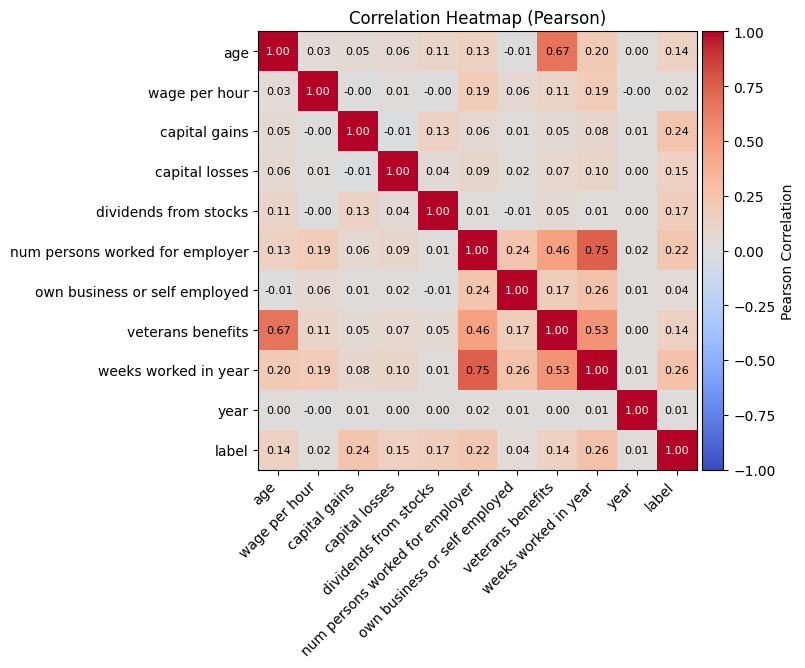

2026-06-18 00:51:10,413 - INFO - Saved figure to figures directory: /Users/jagraves21/notebooks/jpm/census-income-ml-project/data/Census/figures/pearson_correlation_heatmap.png


'/Users/jagraves21/notebooks/jpm/census-income-ml-project/data/Census/figures/pearson_correlation_heatmap.png'

In [9]:
_,fig,ax = visualizations.plot_correlation_heatmap(
    raw_df.assign(
        label=raw_df[target_column].map({
            "50000+.": 1,
            "- 50000.": 0
        })
    ),
    weight_column=weight_column,
    treat_as_categorical=[
        "detailed occupation recode",
        "detailed industry recode"
    ],
    show_values=True,
    figsize=(6,6),
    return_fig=True
)
plt.show()

census.save_figure(fig, "pearson_correlation_heatmap.png")

### Categorical Relationships

A Cramér’s V heatmap is generated to examine associations between categorical features in the dataset. Several integer-coded features are explicitly treated as categorical variables to ensure they are analyzed appropriately. The sample weight column is incorporated into the computation so that the measured associations better reflect the weighted population represented by the data.

Several groups of features exhibit particularly strong relationships:

- `detailed industry recode`, `detailed occupation recode`
- `major industry code`, `major occupation code`
- `region of previous residence`, `state of previous residence`
- `detailed household and family stat`, `detailed household summary in household`
- `migration code-change in msa`, `migration code-change in reg`, `migration code-move within reg`, `live in this house 1 year ago`, `migration prev res in sunbelt`
- `country of birth father`, `country of birth mother`, `country of birth self`, `citizenship`

Additional weaker relationships are also present throughout the dataset.

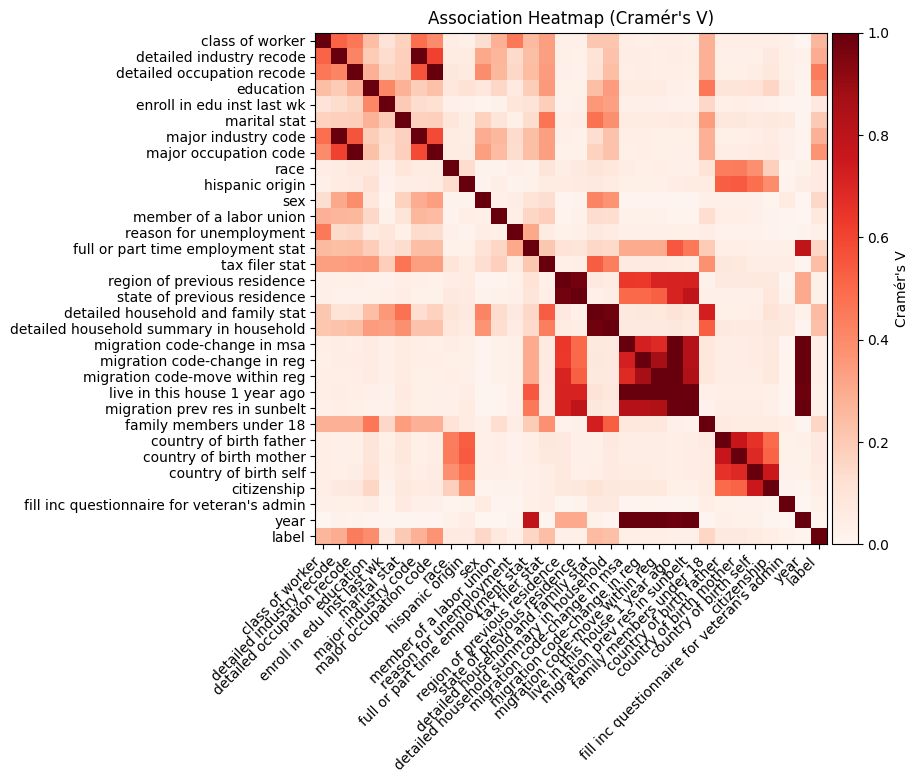

2026-06-18 00:51:40,109 - INFO - Saved figure to figures directory: /Users/jagraves21/notebooks/jpm/census-income-ml-project/data/Census/figures/cramer_v_association_heatmap.png


'/Users/jagraves21/notebooks/jpm/census-income-ml-project/data/Census/figures/cramer_v_association_heatmap.png'

In [10]:
_,fig,ax = visualizations.plot_cramers_v_heatmap(
    raw_df, 
    weight_column=weight_column,
    treat_as_categorical=[
        "detailed occupation recode",
        "detailed industry recode",
        "year",
    ],
    figsize=(7,7),
    return_fig=True
)
plt.show()

census.save_figure(fig, "cramer_v_association_heatmap.png")

### Categorical-Numeric Relationships

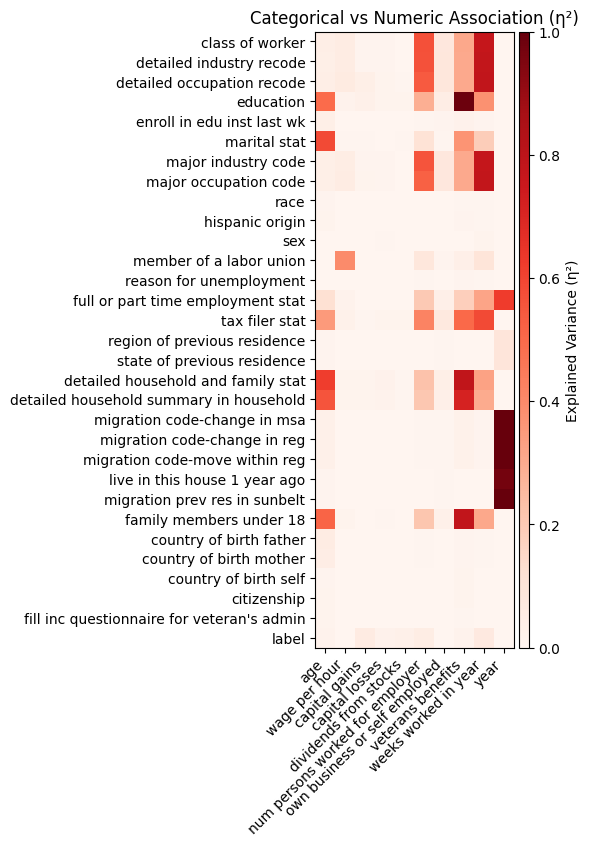

In [11]:
visualizations.plot_mixed_association_heatmap(
    raw_df,
    weight_column=weight_column,
    treat_as_categorical=[
        "detailed occupation recode",
        "detailed industry recode"
    ],
    aspect="equal",
    figsize=(8,8)
)

## Numeric–Categorical Feature Identification

A predefined set of numerically encoded categorical features is retrieved and displayed. These features are stored as numeric codes but represent discrete categorical variables rather than continuous numerical measurements.

In [12]:
numeric_categorical_features = census.get_numeric_categorical_features()
print("Numeric Categorical Features:")
print("\n".join(f"  - {feature}" for feature in numeric_categorical_features))

categorical_columns, numeric_columns = ml_utils.get_categorical_numeric_split(
    raw_df,
    treat_as_categorical=["age"] + numeric_categorical_features
)

plot_kwargs = dict()
for column in numeric_categorical_features + ["age", "year"]:
    plot_kwargs[column] = {
        "_dist": {
            "horizontal":False,
            "sort_by_category":True
        }
    }

Numeric Categorical Features:
  - own business or self employed
  - num persons worked for employer
  - detailed occupation recode
  - major occupation code
  - detailed industry recode
  - major industry codeveterans benefits


## Demographics

These describe personal and family identity.

- The `age` feature has a high concentration at 90, possibly due to top-coding (i.e., ages 90+ grouped together). This should be verified.

- The `hispanic origin` feature has no explicit category for non-Hispanic individuals. Given the relatively small number of missing values, it is possible that non-Hispanic respondents were grouped into the `All other` category. This should be verified.

- The `country of birth self`, `country of birth father`, and `country of birth mother` features all contain a `?` category. This most likely indicates that the respondent’s country of birth was not recorded, not provided, or could not be determined. This is probably a missing value. This should be verified.

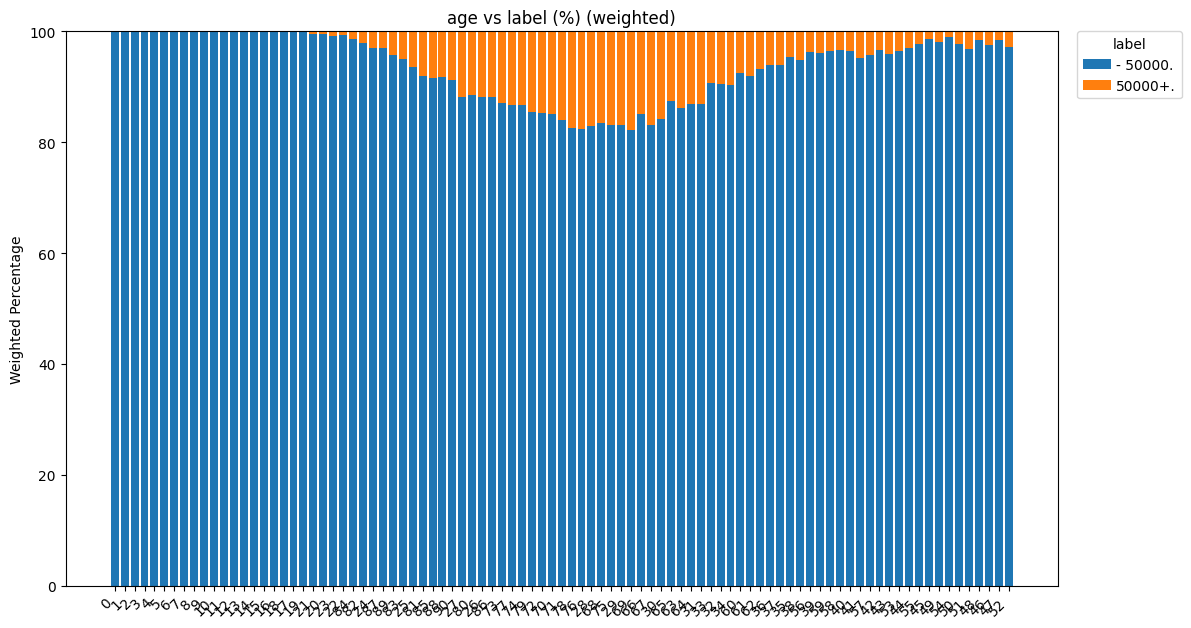

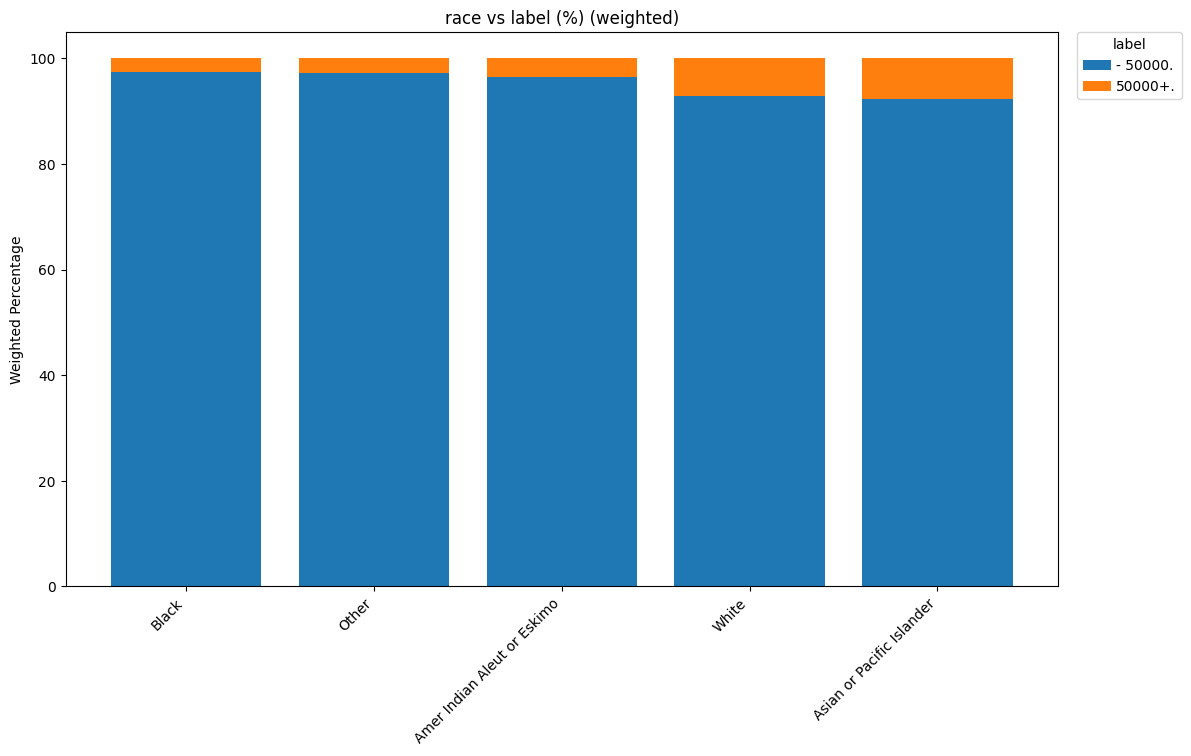

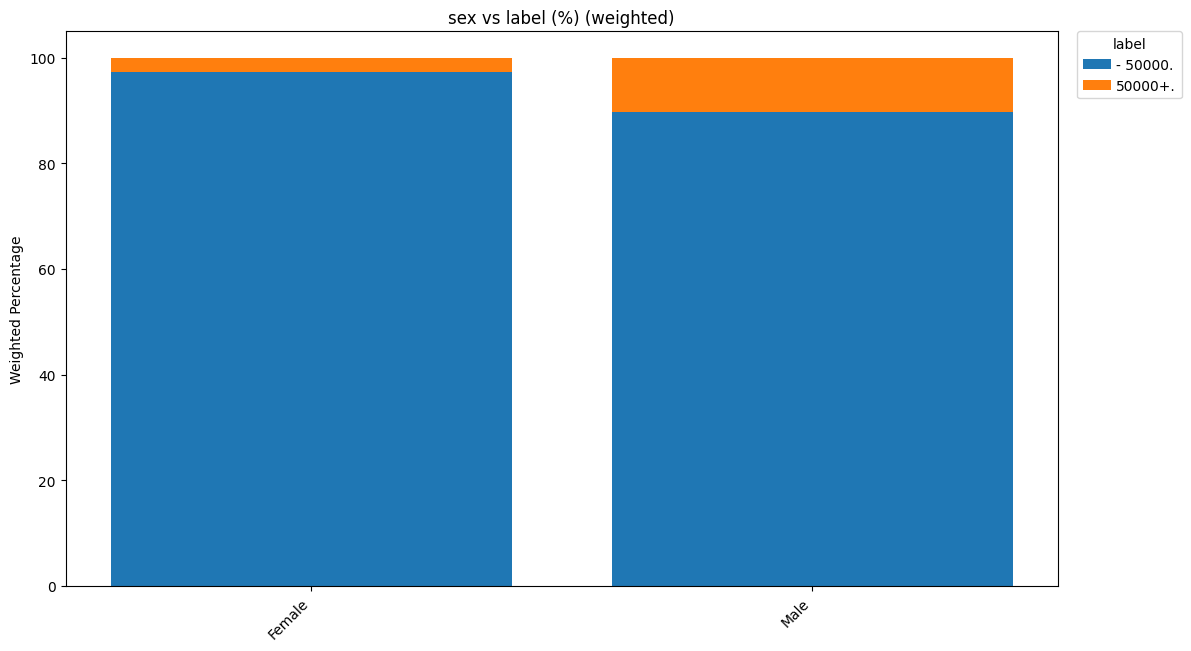

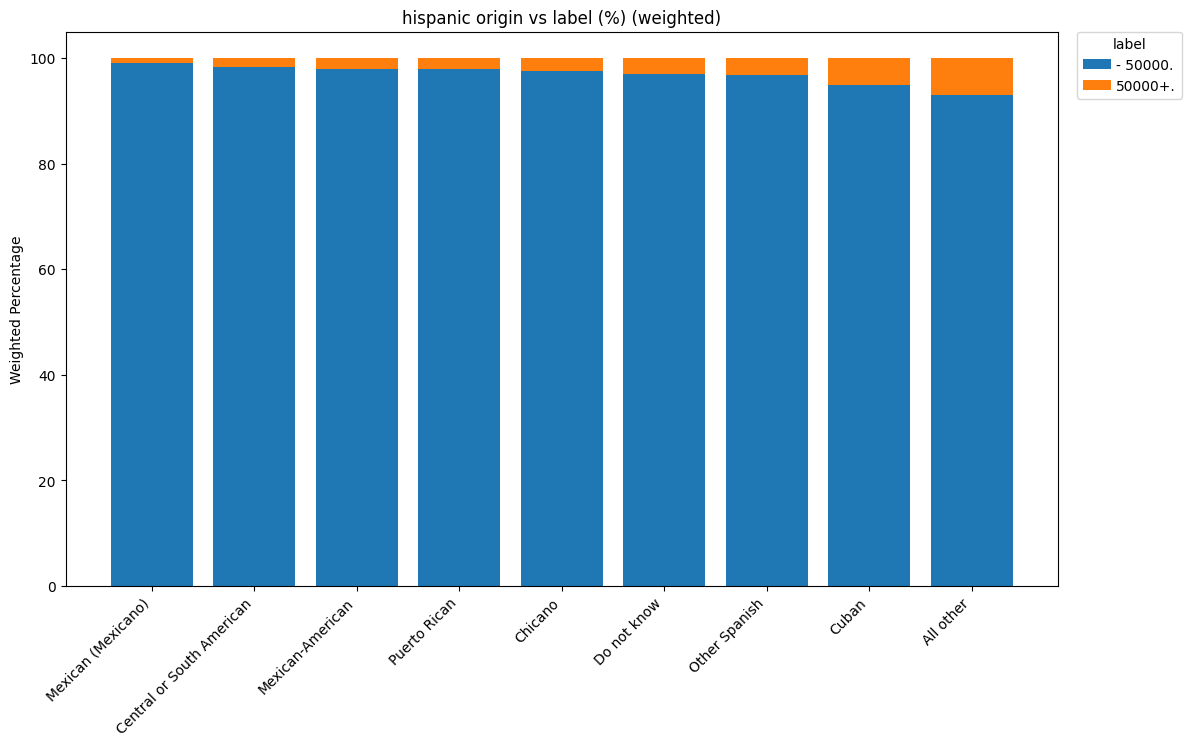

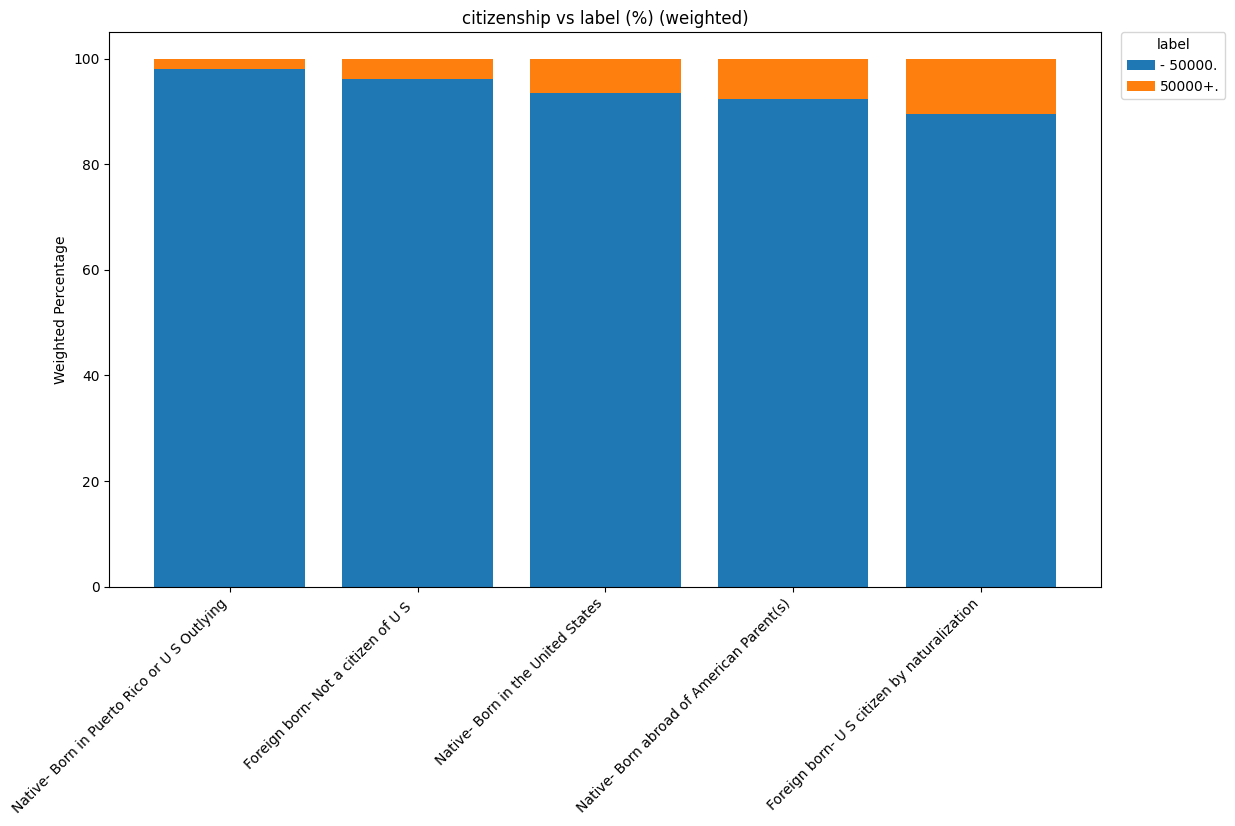

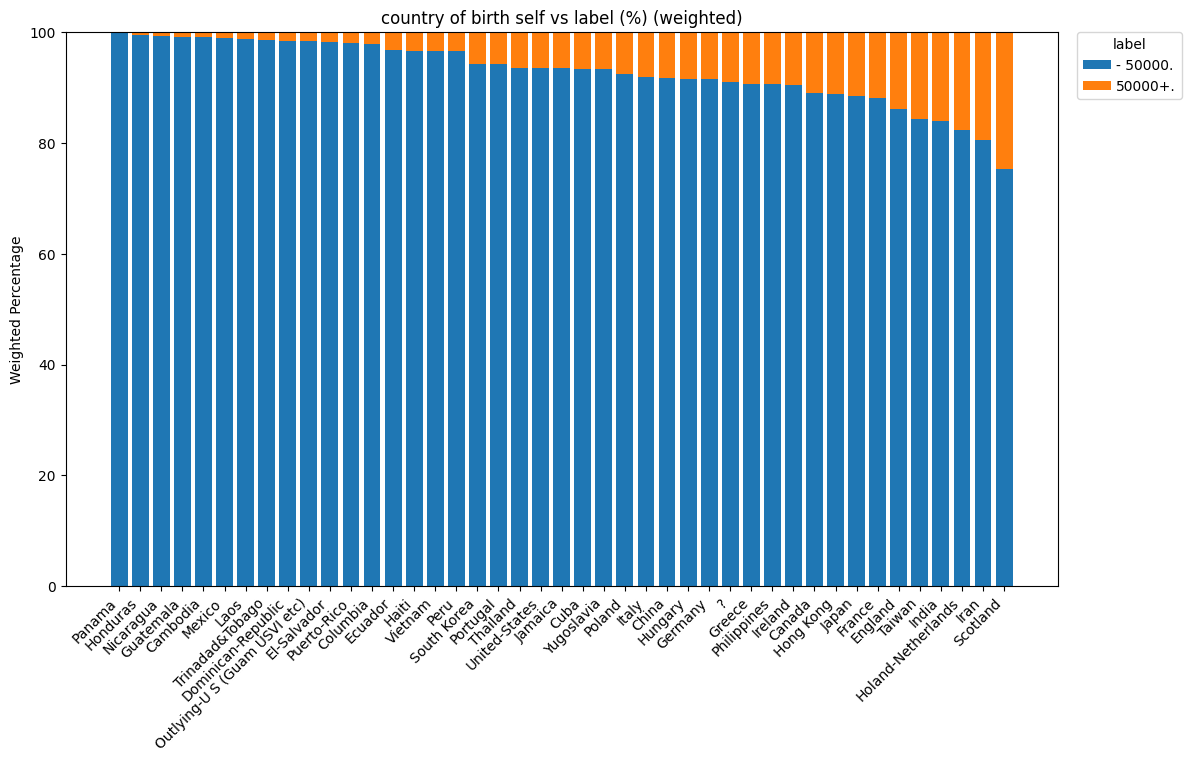

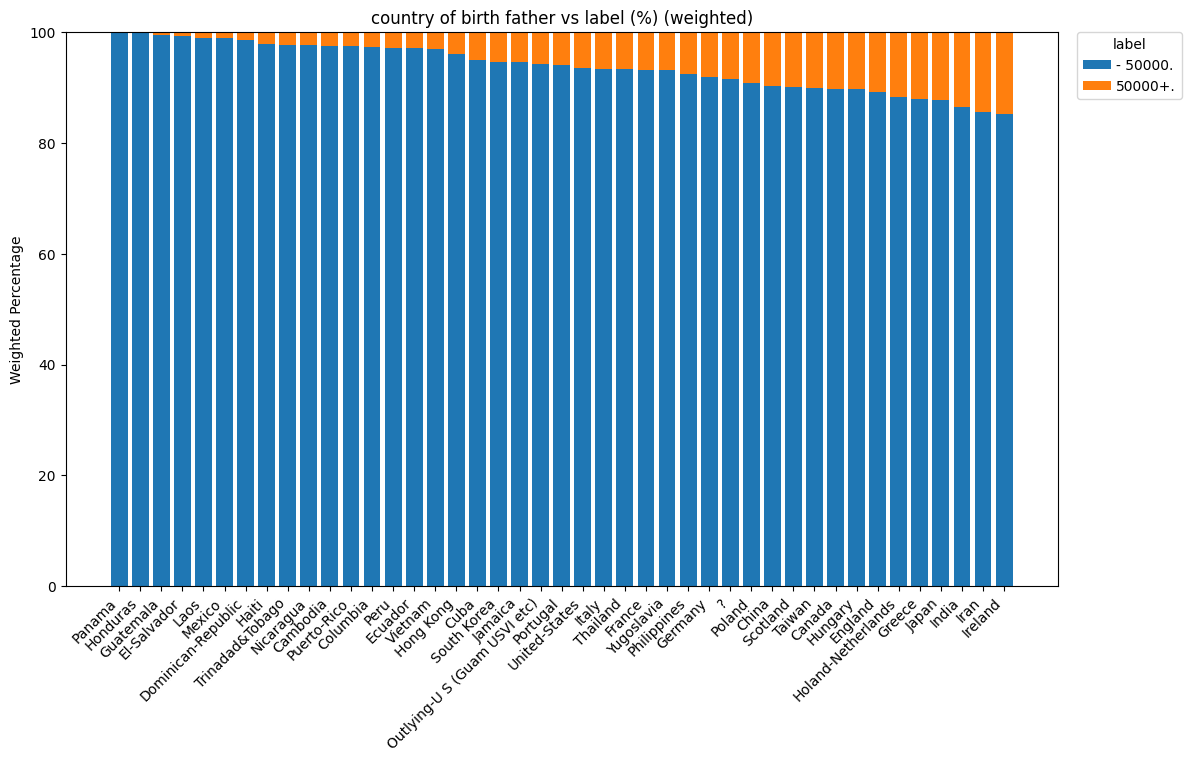

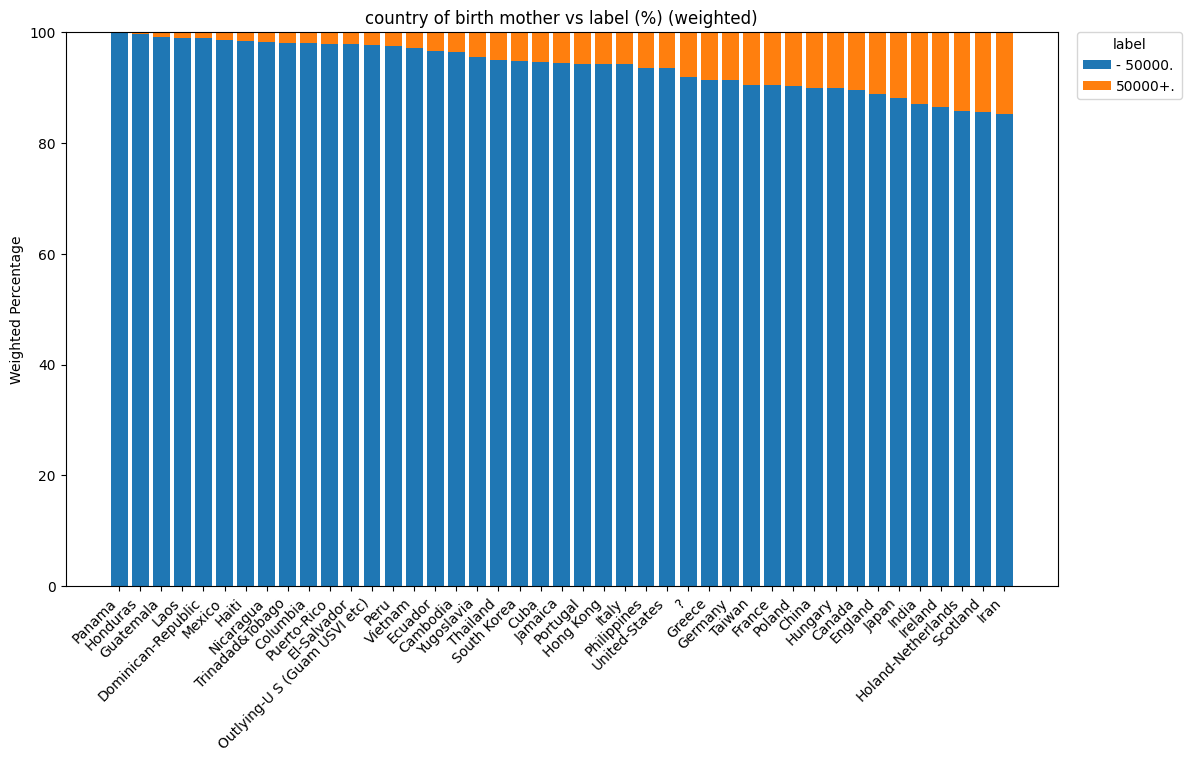

In [13]:
demographics = [
    "age",
    "race",
    "sex",
    "hispanic origin",
    "citizenship",
    "country of birth self",
    "country of birth father",
    "country of birth mother"
]

visualizations.plot_feature_group(
    raw_df,
    demographics,
    numeric_categorical_columns=["age"] + numeric_categorical_features,
    plot_kwargs=plot_kwargs
)

## Education and Schooling

These capture education level and current schooling status.

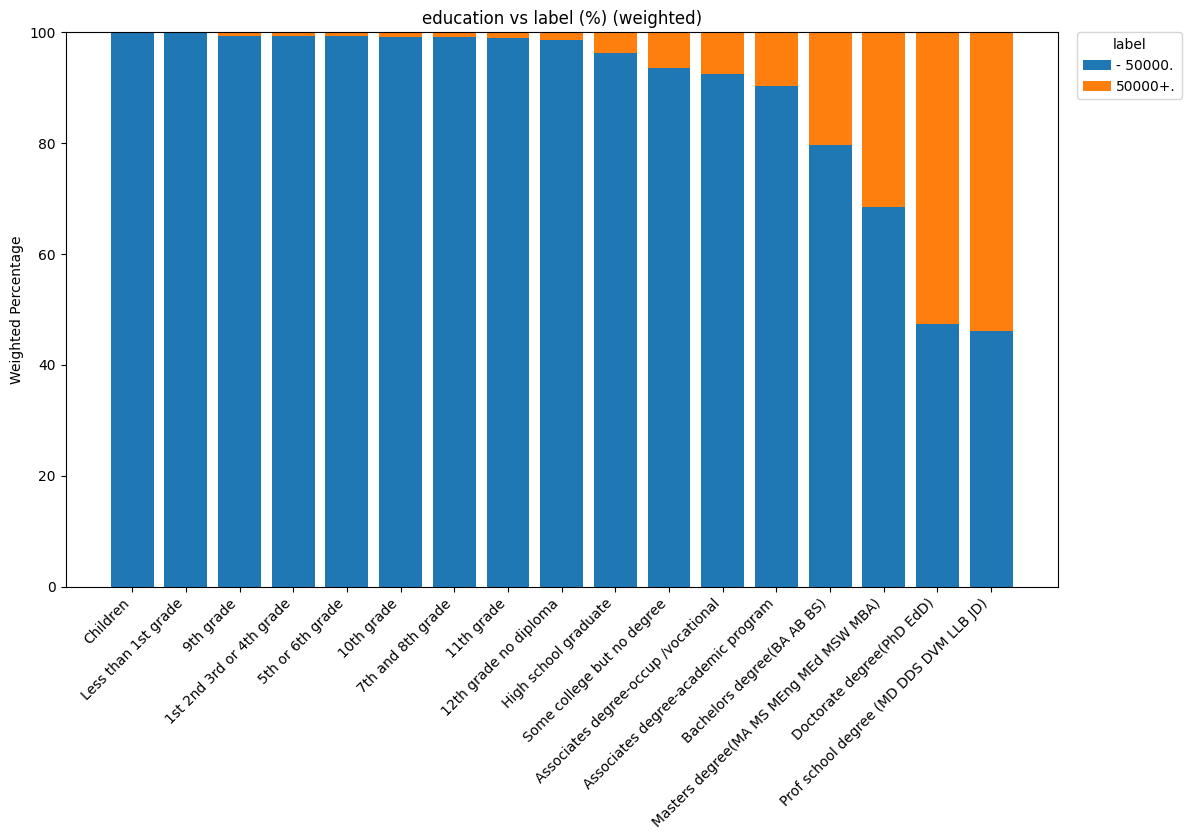

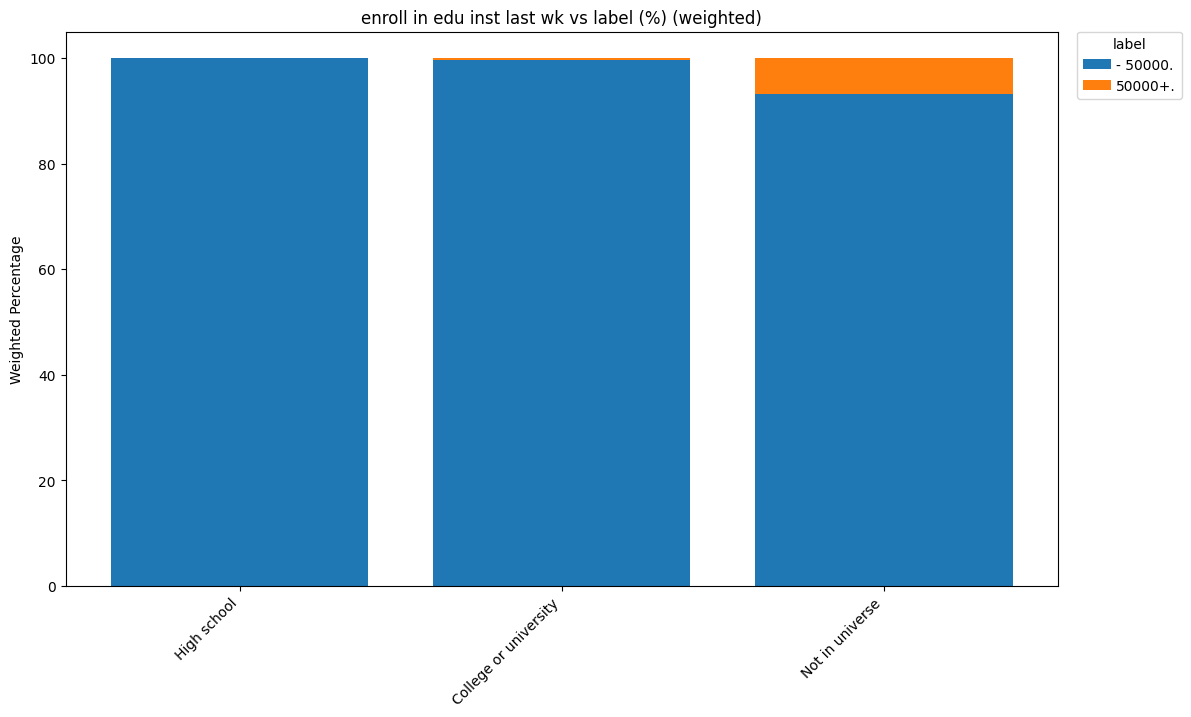

In [14]:
education_and_schooling = [
    "education",
    "enroll in edu inst last wk"
]

visualizations.plot_feature_group(
    raw_df,
    education_and_schooling,
    numeric_categorical_columns=numeric_categorical_features,
    plot_kwargs=plot_kwargs
)

## Employment Type and Job Structure

These describe the kind of work and job classification.

- The `full or part time employment stat` feature has a category called `Children or Armed Forces`. This is likely a grouping for individuals who are excluded from standard employment classification. This should be verified.

- The `own business or self employed` feature is stored as an integer but is most likely categorical. It has values `0`, `1`, and `2`. The `0` value has the highest frequency by far. This may indicate that `0` is the Not in Universe category for this feature, though this should be verified. If the encoding cannot be confirmed or better understood, this feature should not be used in models requiring interpretability.

- The `num persons worked for employer` feature is stored as an integer and has a large number of `0` values. It is unclear whether `0` represents a legitimate numeric value (e.g., no employees) or a Not in Universe category. Given the limited set of values observed, this feature may represent a categorical variable encoded numerically rather than a true continuous numeric feature. This should be verified before use.

- The `detailed occupation recode` feature likely indicates a more fine grained subclass of the `major occupation code` feature. It takes integer values between 0 and 45. There is an overwhelming number of 0 values, and it is unclear whether these indicate Not in Universe. This should be verified before use.

- The `major occupation code` feature appears to be a higher level grouping of the `detailed occupation recode` feature. It is categorical with string values and includes a `Not in universe` category.

- The `detailed industry recode` feature likely indicates a more fine grained subclass of the `major industry code` feature. It takes integer values between 0 and 51. There is an overwhelming number of 0 values, and it is unclear whether these indicate Not in Universe. This should be verified before use.

- The `major industry code` feature appears to be a higher level grouping of the `detailed industry recode` feature. It is categorical with string values and includes a `Not in universe` category.

> Both the `own business or self employed` and `num persons worked for employer` features seem like the would be ueful for predicting income level, but their encodings should be verified and properly understood before they are included in modeling.

> Occupation and industry code pairs may be correlated if one serves as a hierarchical breakdown of the other. This could introduce redundancy and multicollinearity if used together in a model.

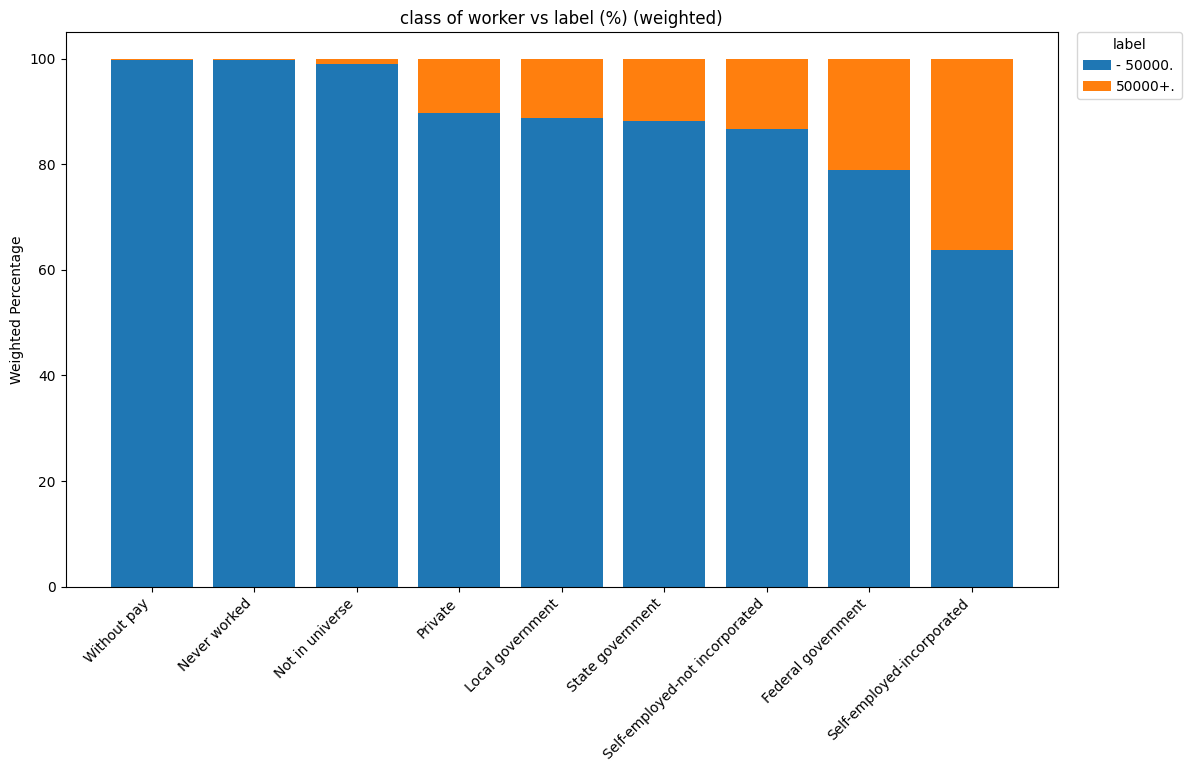

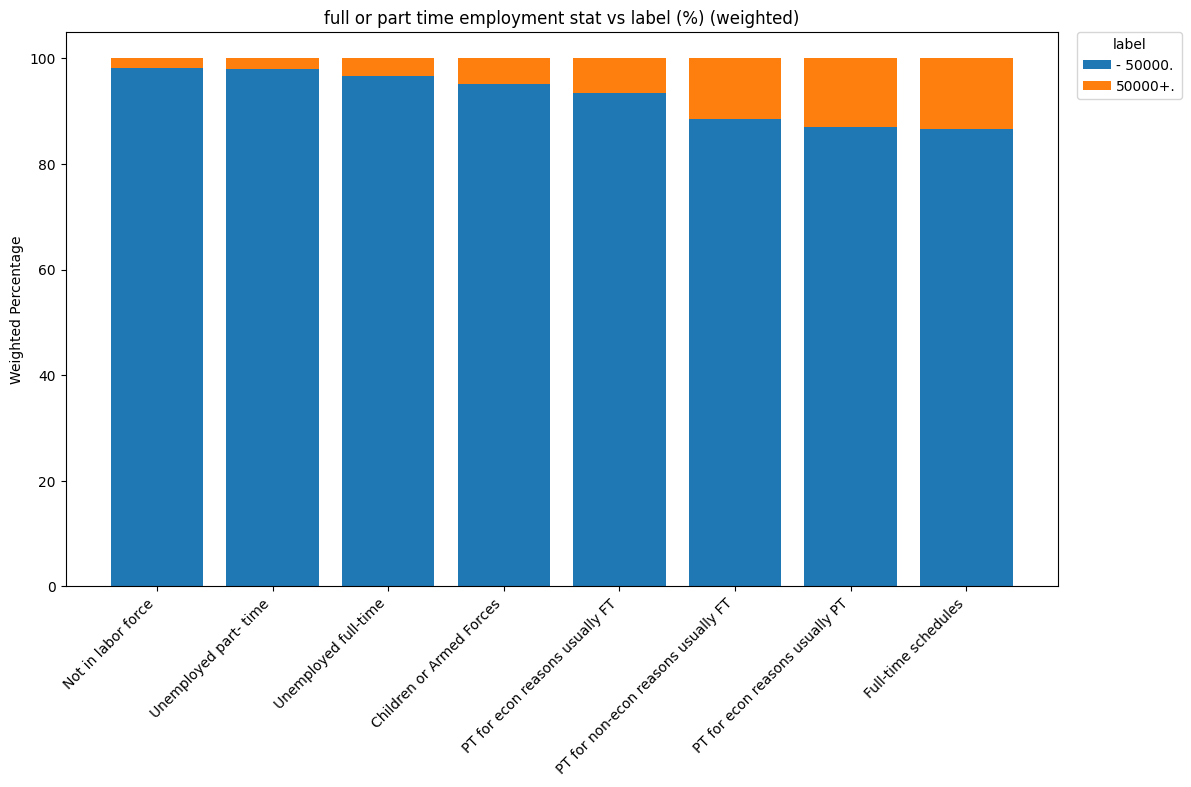

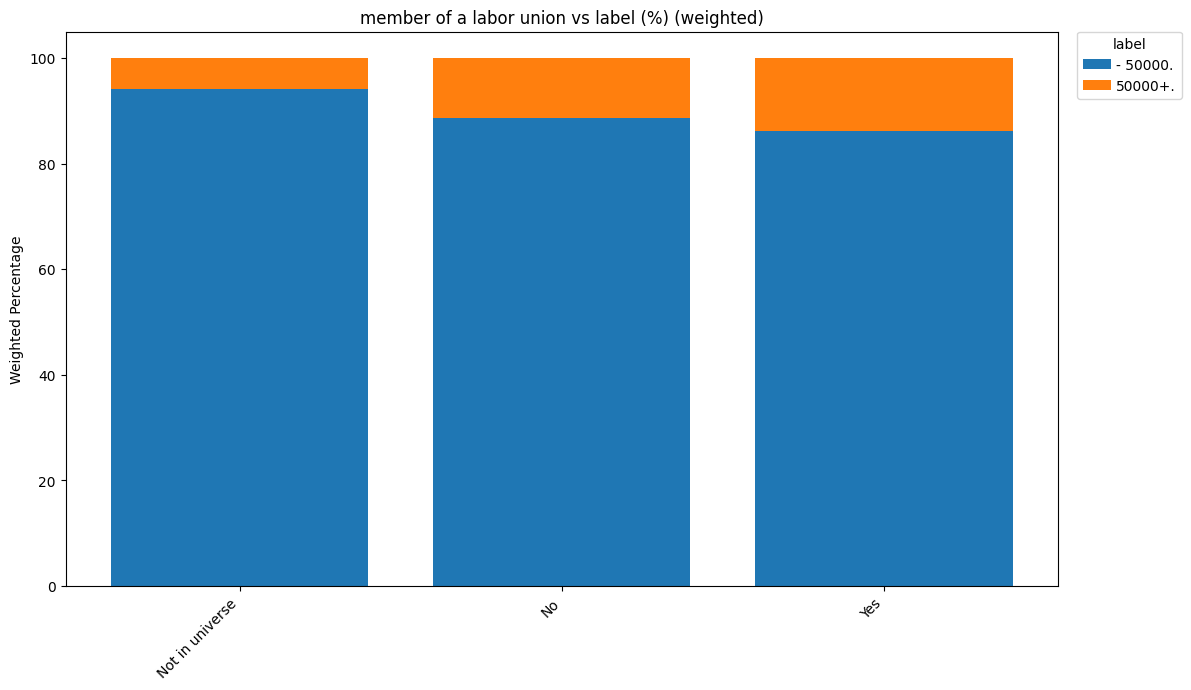

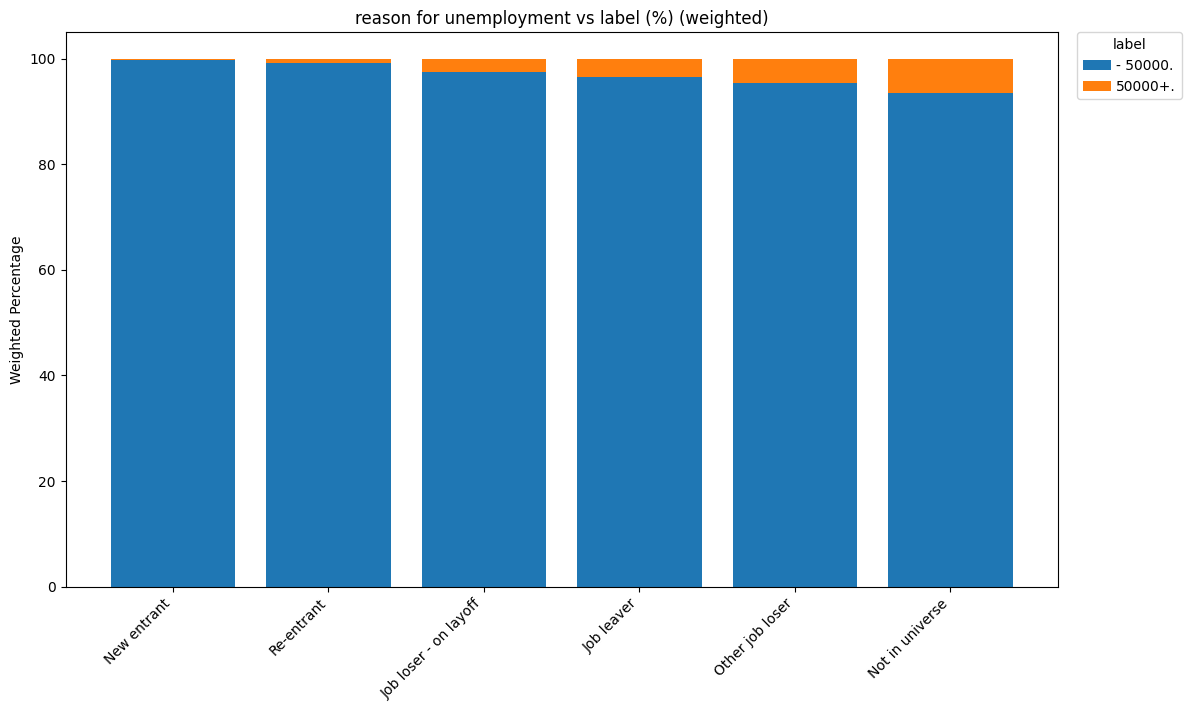

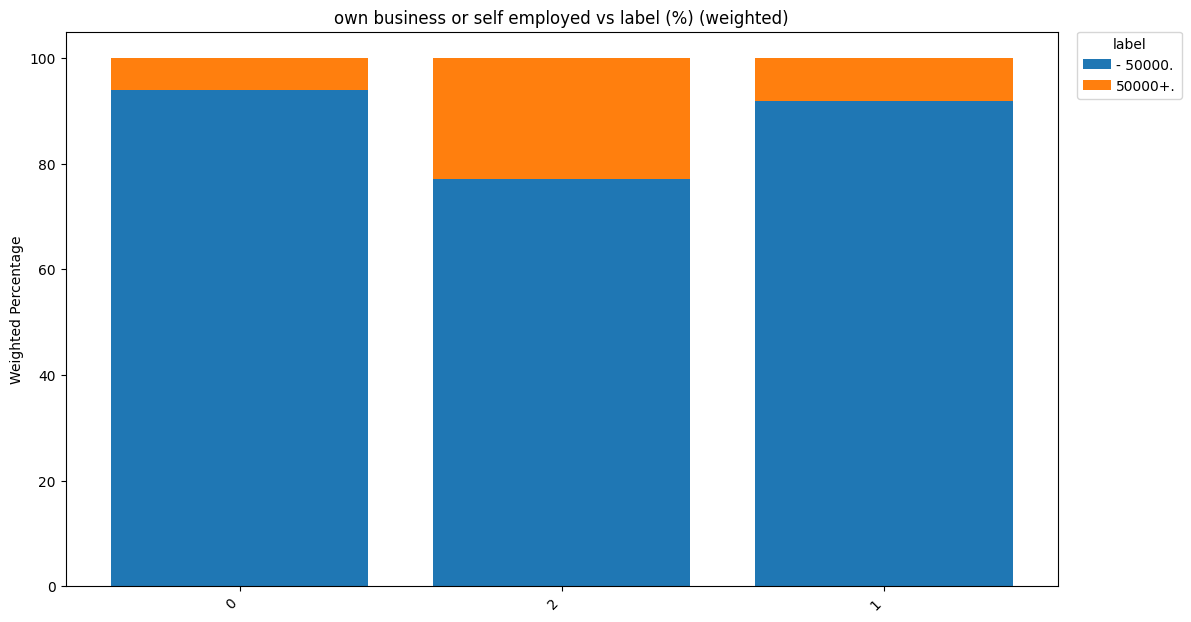

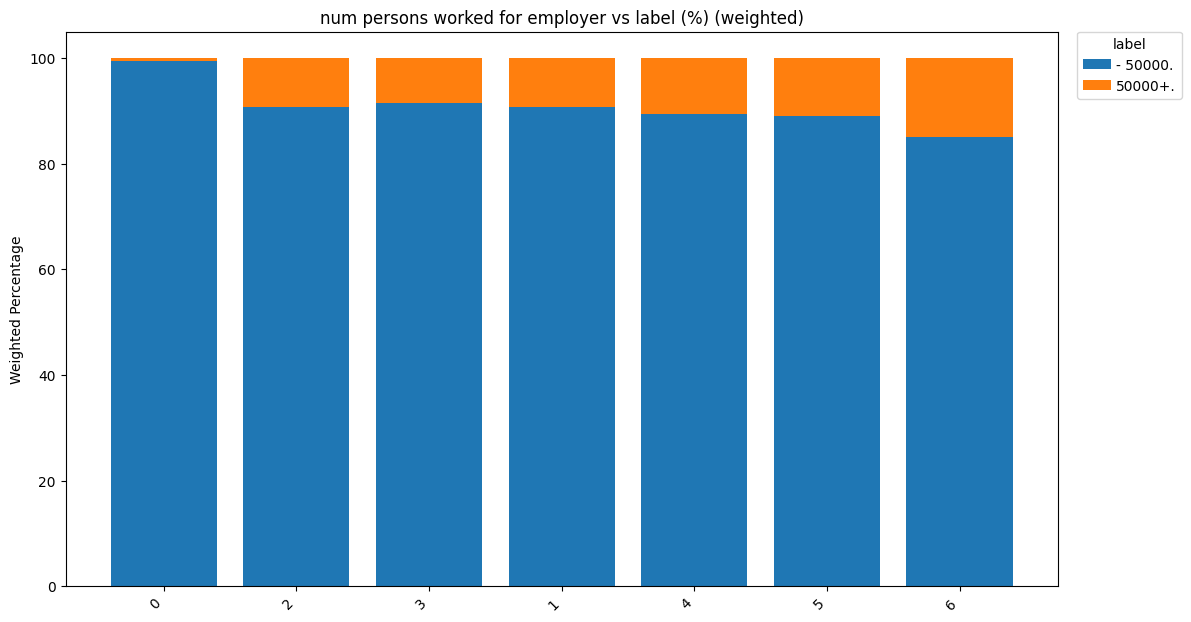

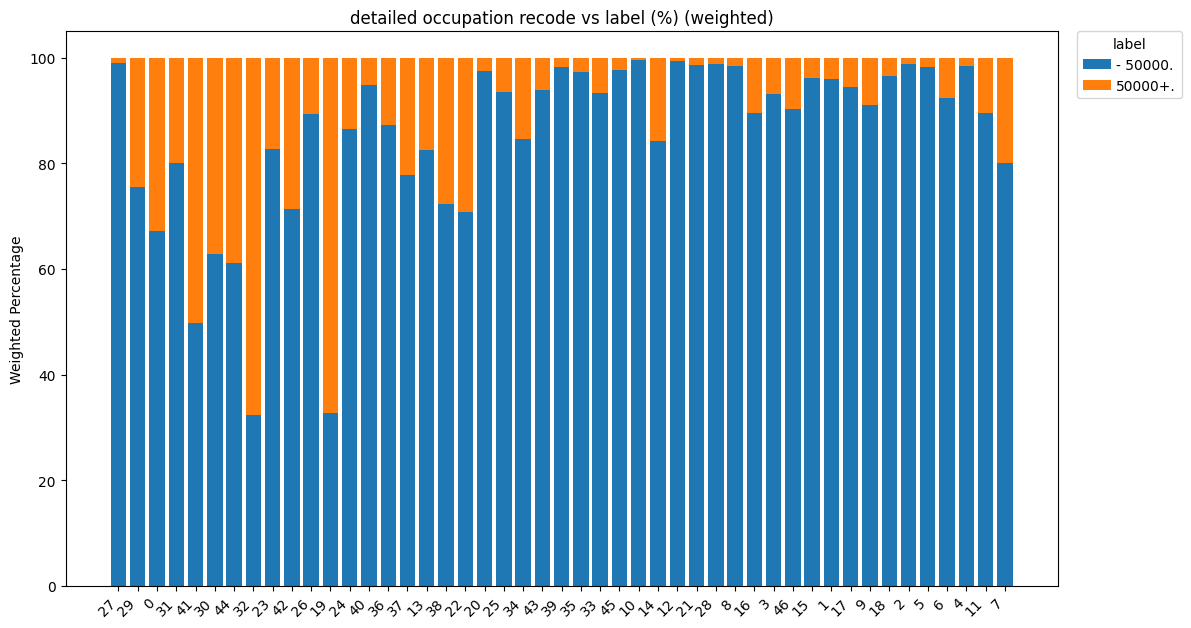

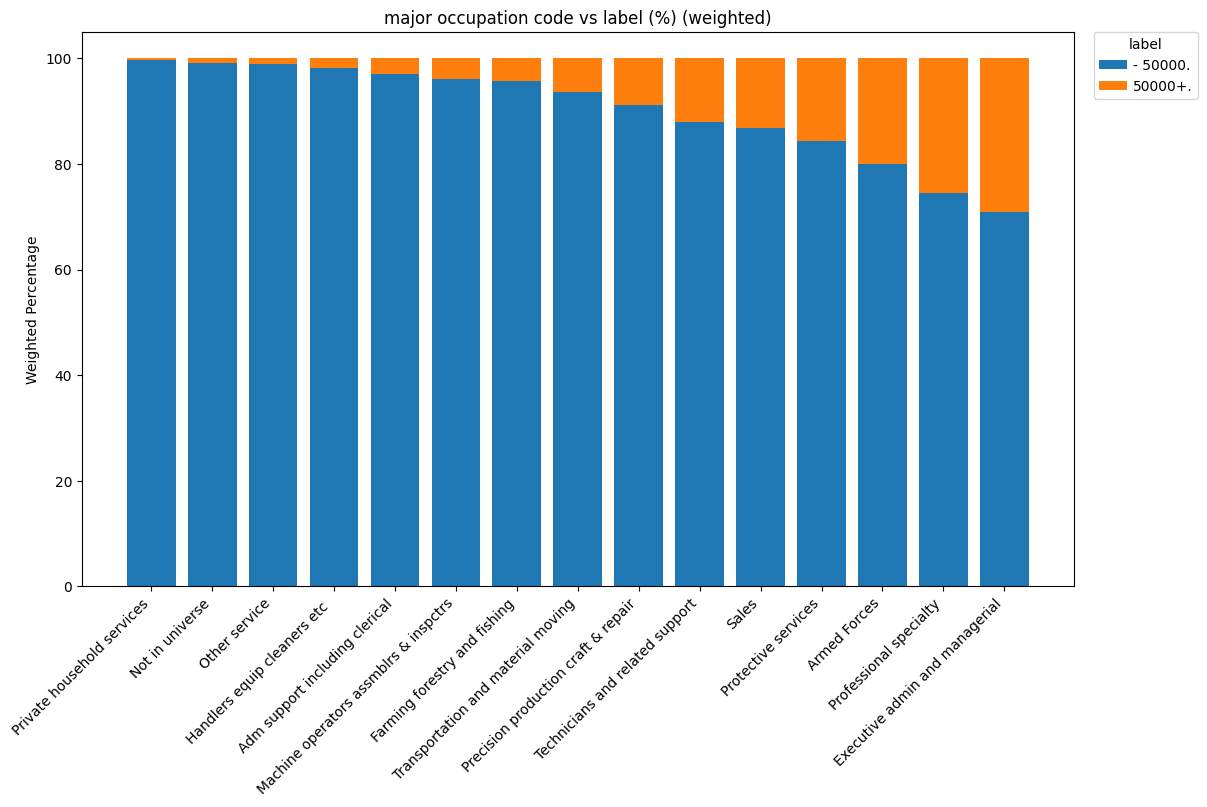

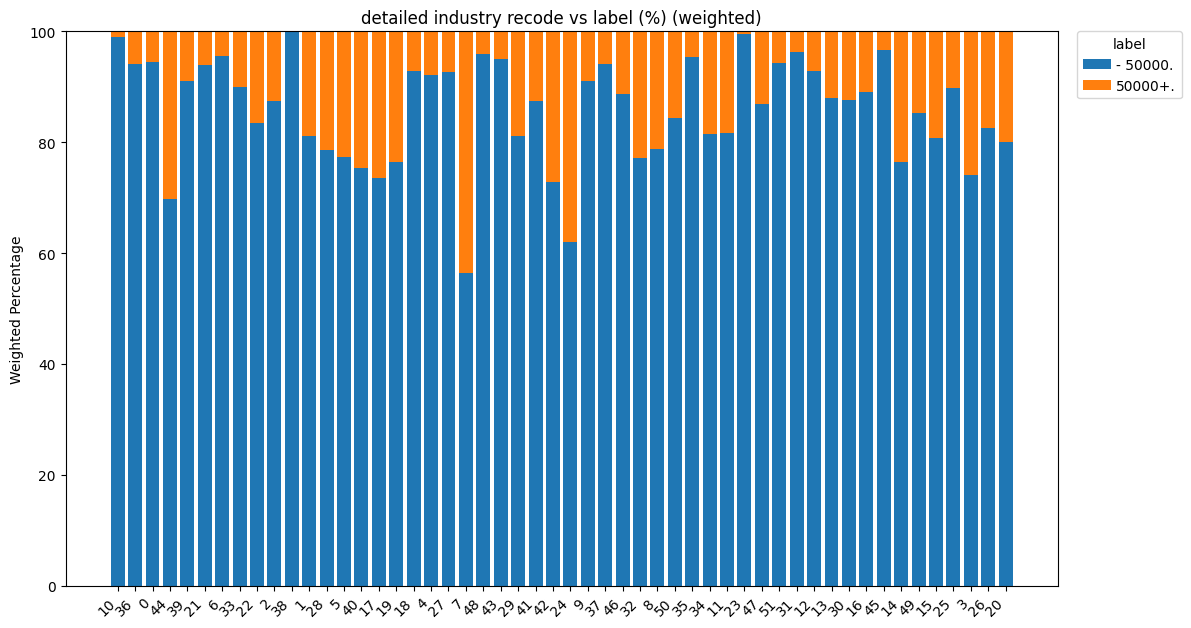

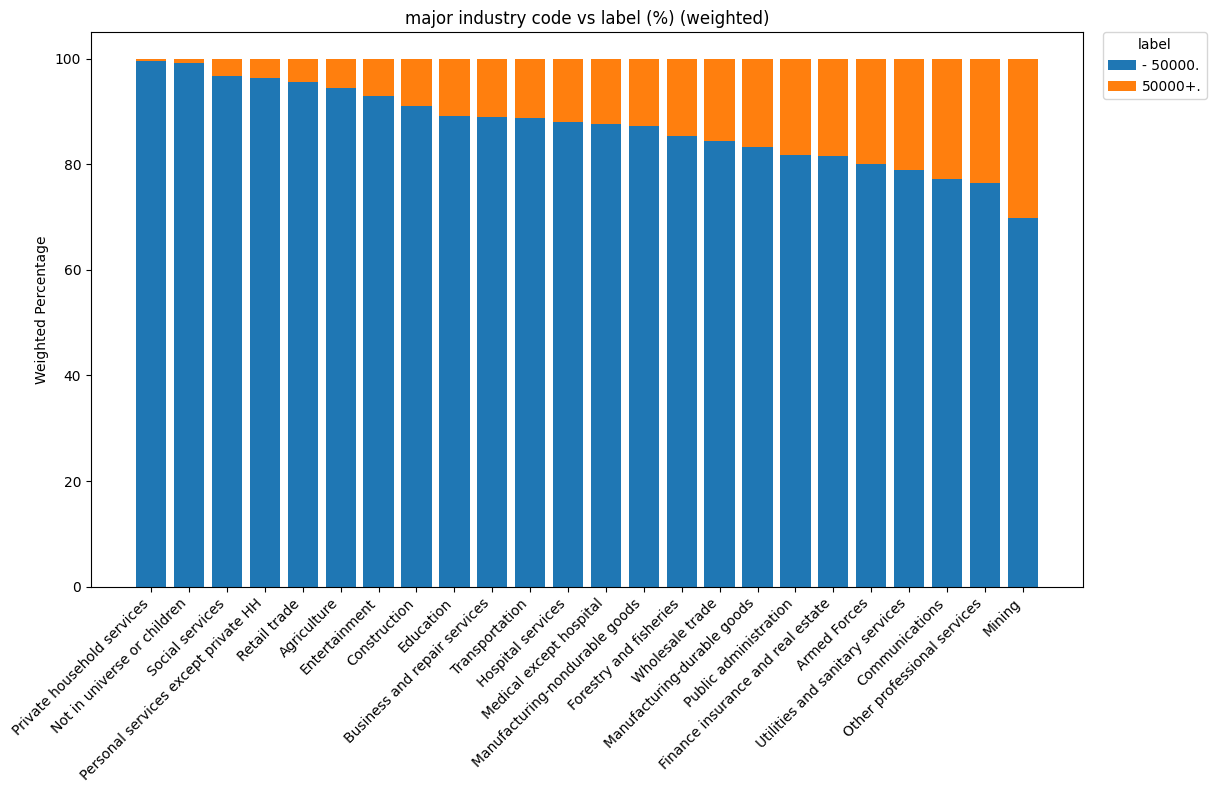

niu_mask.sum()=np.int64(100684)
zero_mask.sum()=np.int64(100684)
100684


niu_mask.sum()=np.int64(100684)
zero_mask.sum()=np.int64(100684)
100684


In [15]:
employment_type_and_job_structure = [
    "class of worker",
    "full or part time employment stat",
    "member of a labor union",
    "reason for unemployment",
    "own business or self employed",
    "num persons worked for employer",
    "detailed occupation recode",
    "major occupation code",
    "detailed industry recode",
    "major industry code"
]

visualizations.plot_feature_group(
    raw_df,
    employment_type_and_job_structure,
    numeric_categorical_columns=numeric_categorical_features,
    plot_kwargs=plot_kwargs
)

display(HTML("<h3>Industry NIU/0 Check</h3>"))
niu_mask = raw_df["major industry code"].eq("Not in universe or children")
zero_mask = raw_df["detailed industry recode"].eq(0)
print(f"{niu_mask.sum()=}")
print(f"{zero_mask.sum()=}")
print(f"{(niu_mask & zero_mask).sum()}")

display(HTML("<h3>Occupation NIU/0 Check</h3>"))
niu_mask = raw_df["major occupation code"].eq("Not in universe")
zero_mask = raw_df["detailed occupation recode"].eq(0)
print(f"{niu_mask.sum()=}")
print(f"{zero_mask.sum()=}")
print(f"{(niu_mask & zero_mask).sum()}")

## Income and Financial Indicators

These tend to be strong predictors of income.

- There appears to be a cap at 10,000 for `wage per hour`.
- There appears to be a cap at 100,000 for `capital gains` and `dividends from stocks`.

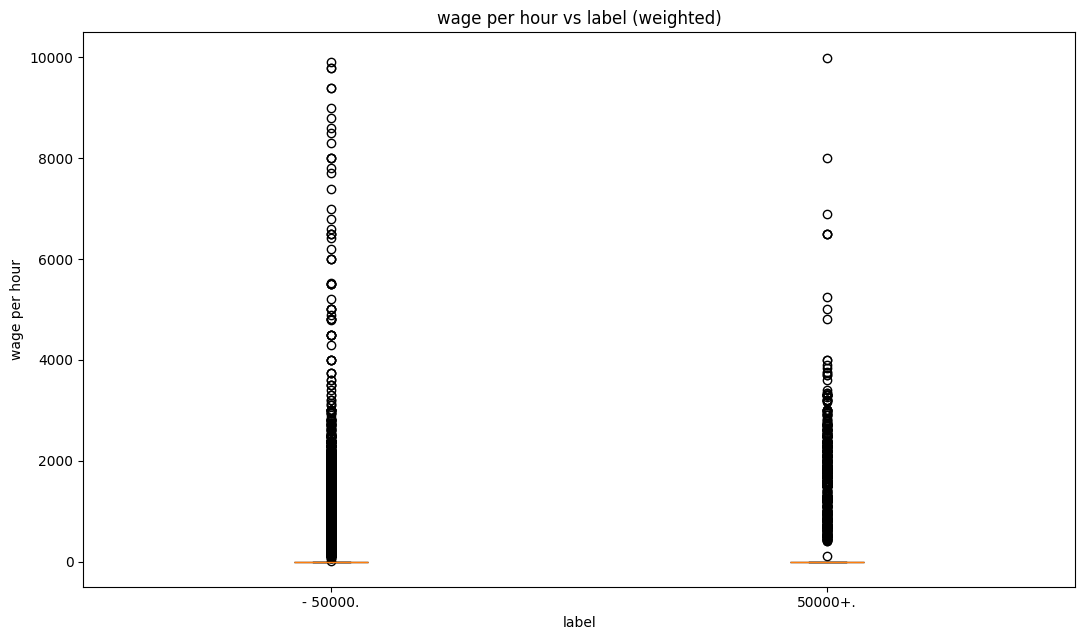

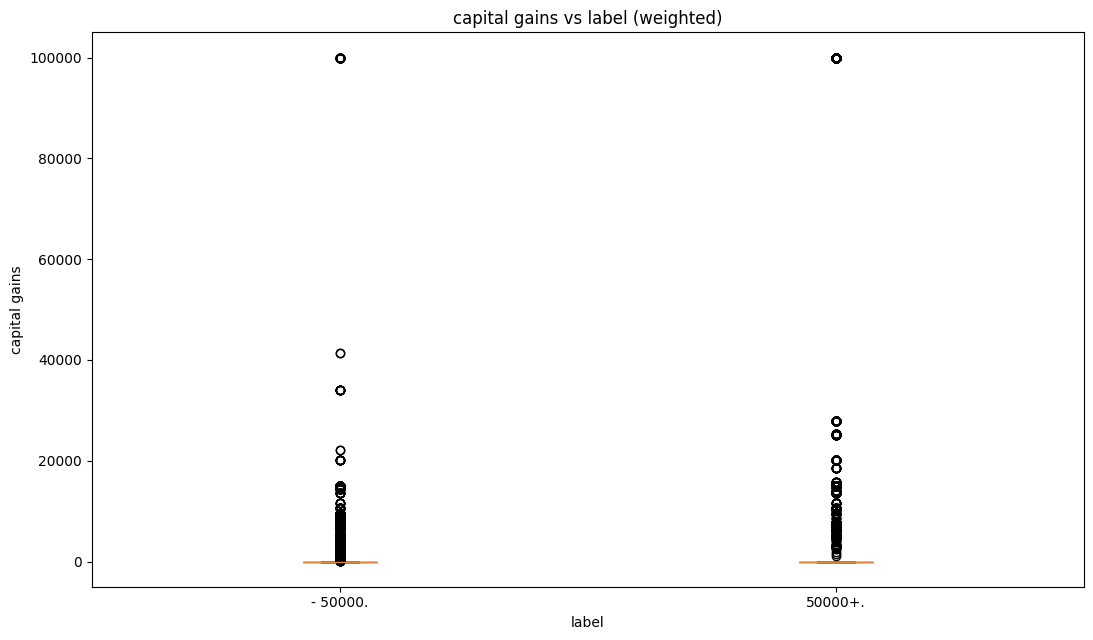

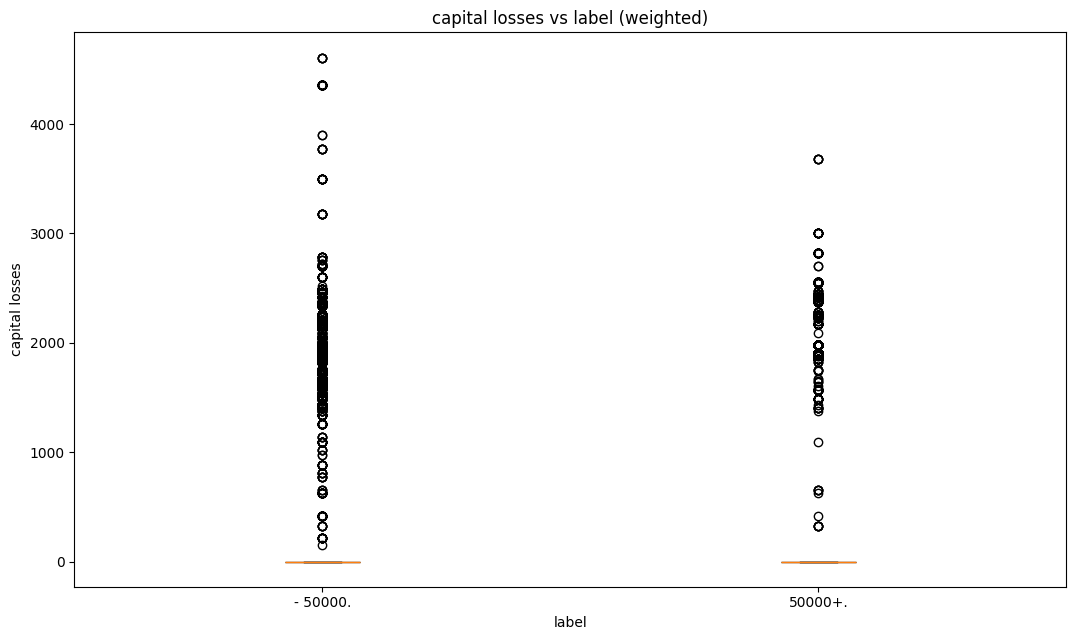

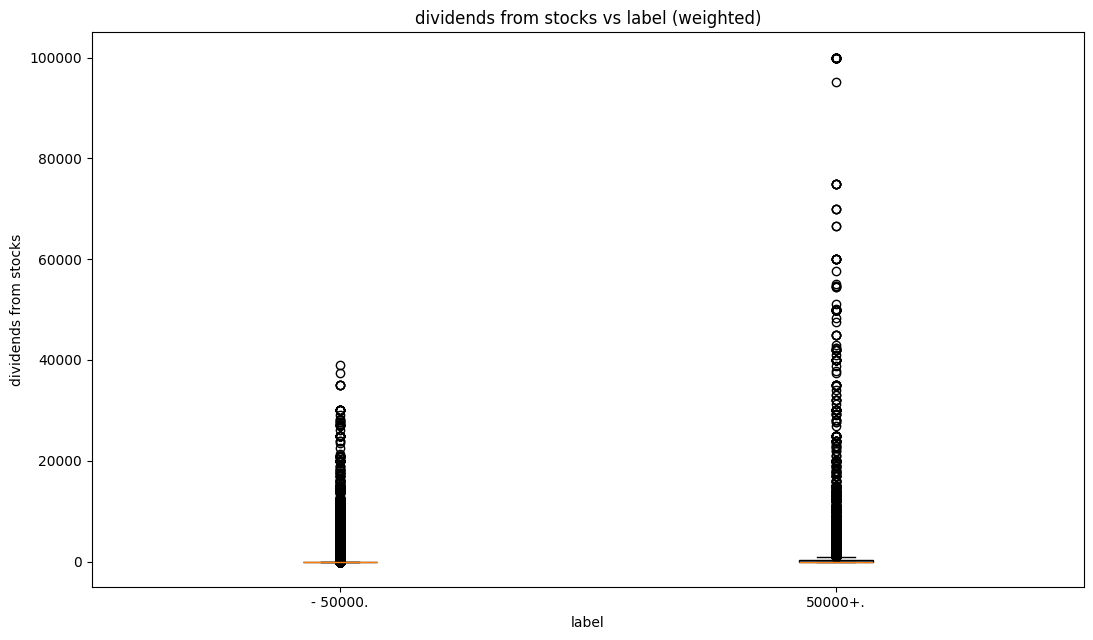

In [16]:
income_and_financial_indicators = [
    "wage per hour",
    "capital gains",
    "capital losses",
    "dividends from stocks"
]

visualizations.plot_feature_group(
    raw_df,
    income_and_financial_indicators,
    numeric_categorical_columns=numeric_categorical_features,
    plot_kwargs=plot_kwargs
)

## Work History

These describe work intensity and employment duration.

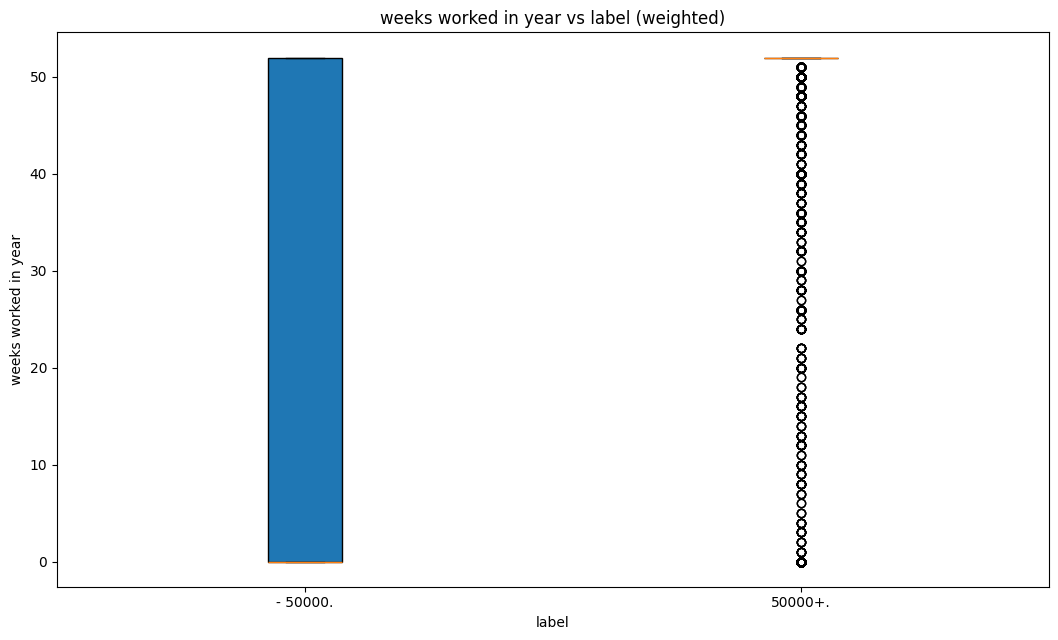

In [17]:
work_history = [
    "weeks worked in year"
]

visualizations.plot_feature_group(
    raw_df,
    work_history,
    numeric_categorical_columns=numeric_categorical_features,
    plot_kwargs=plot_kwargs
)

## Veteran and Military Status

These indicate administrative benefits.

- The `veterans benefits` feature is recorded as an integer taking on the values `0`, `1`, and `2`. It is not clear whether any of these values correspond to a Not in Nniverse category. Care should be taken when using this feature, and its encoding should be verified before interpretation or modeling.

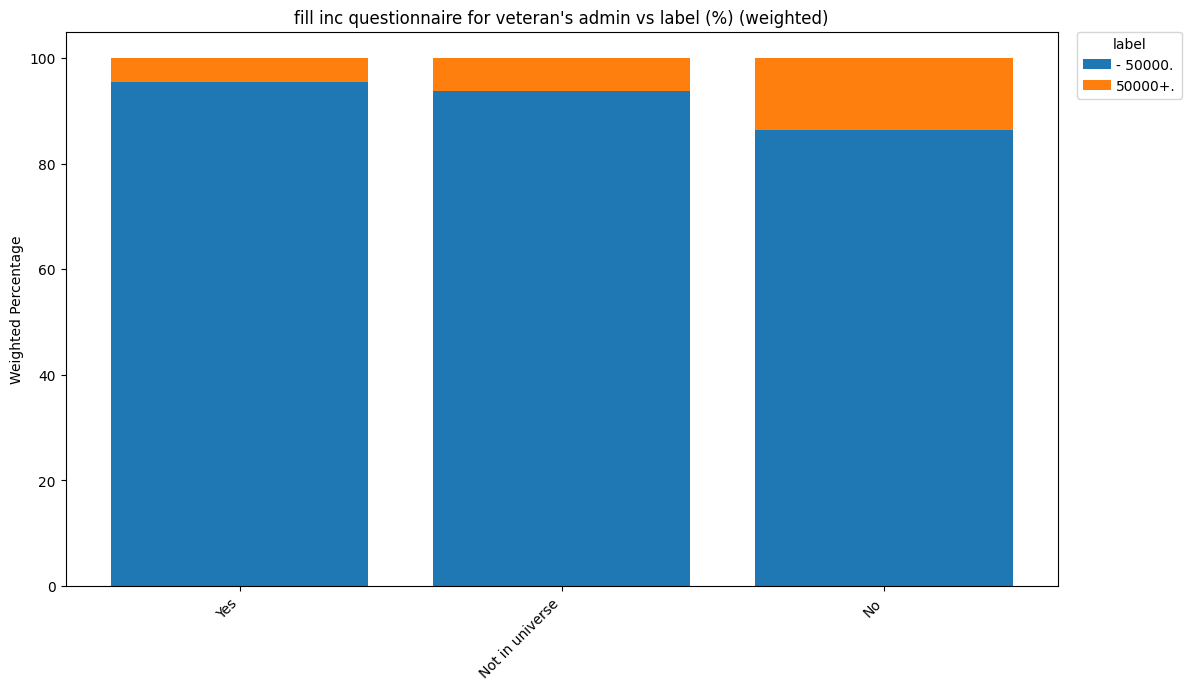

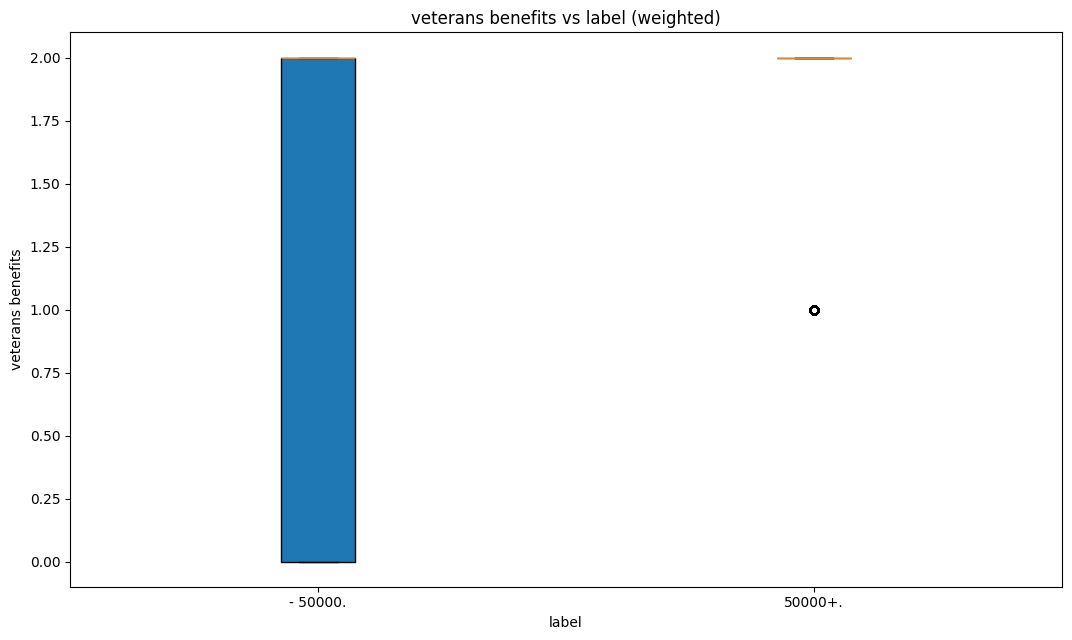

In [18]:
veteran_and_military_status = [
    "fill inc questionnaire for veteran's admin",
    "veterans benefits"
]

visualizations.plot_feature_group(
    raw_df,
    veteran_and_military_status,
    numeric_categorical_columns=numeric_categorical_features,
    plot_kwargs=plot_kwargs
)

## Household and Family Structure

These describe household composition and filing status.

- `marital stat`: legal marital status of the individual

- `detailed household and family stat`: individual's role within the household or family (e.g., householder, child, spouse)

- `detailed household summary in household`: overall household type (e.g., family, non family, single person)

- `family members under 18`: not sure what this is

- `tax filer stat`: individual's role in tax filing

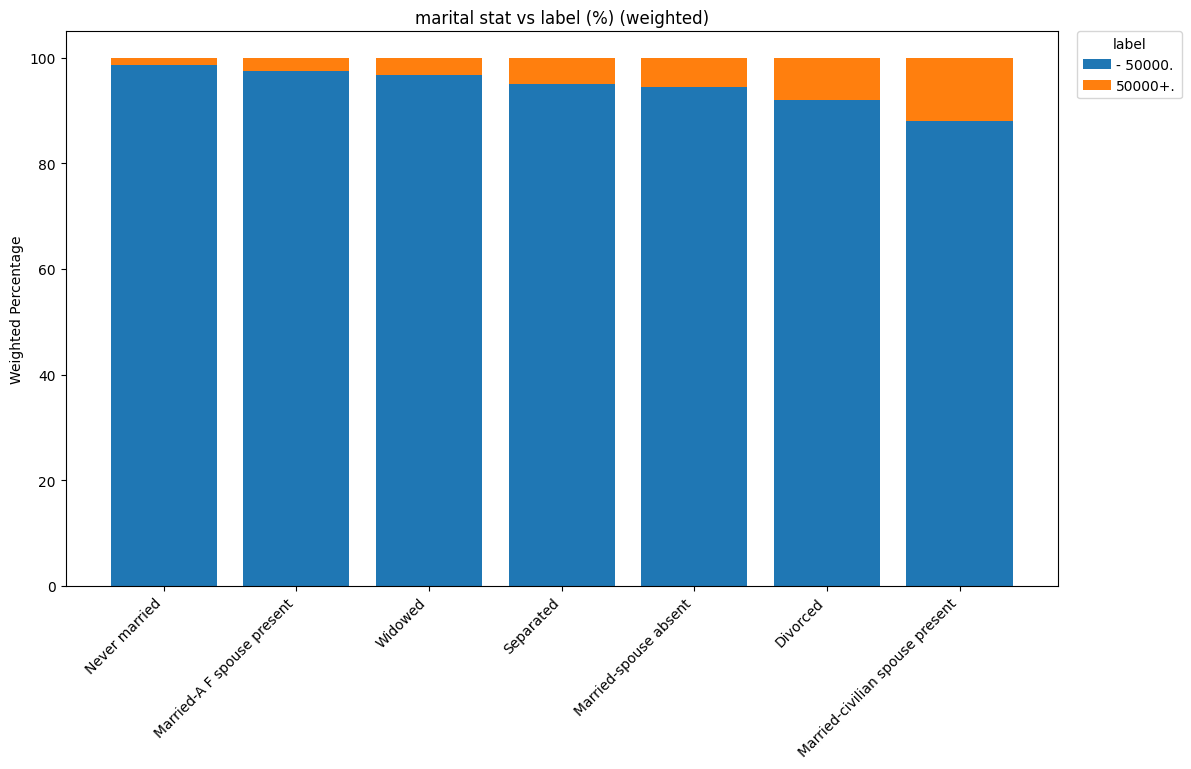

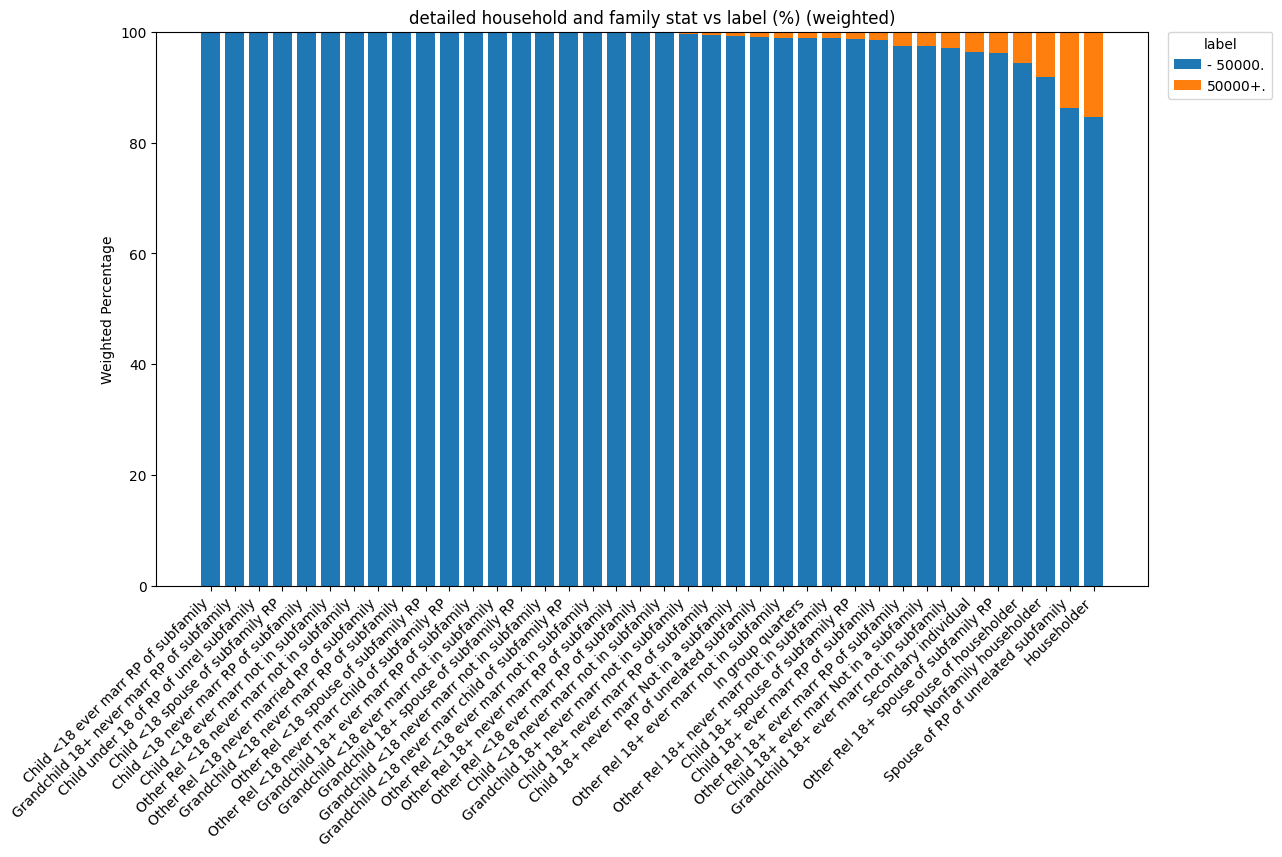

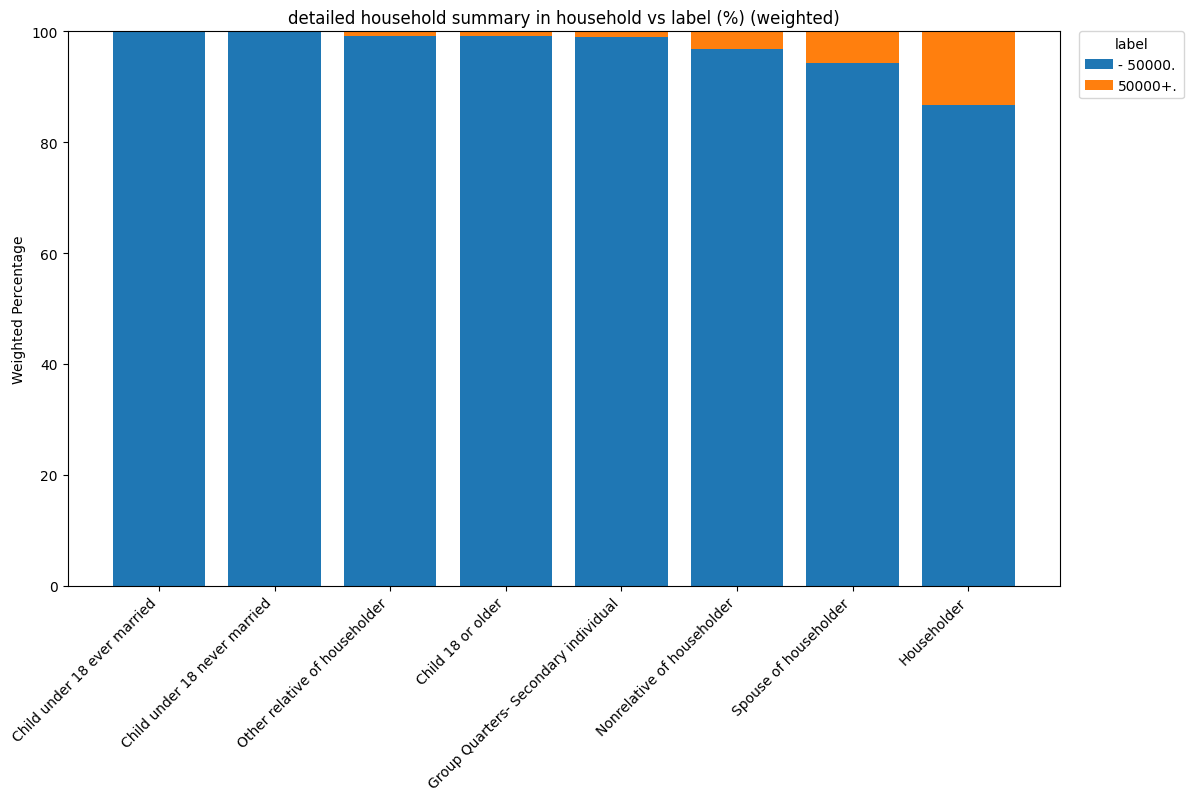

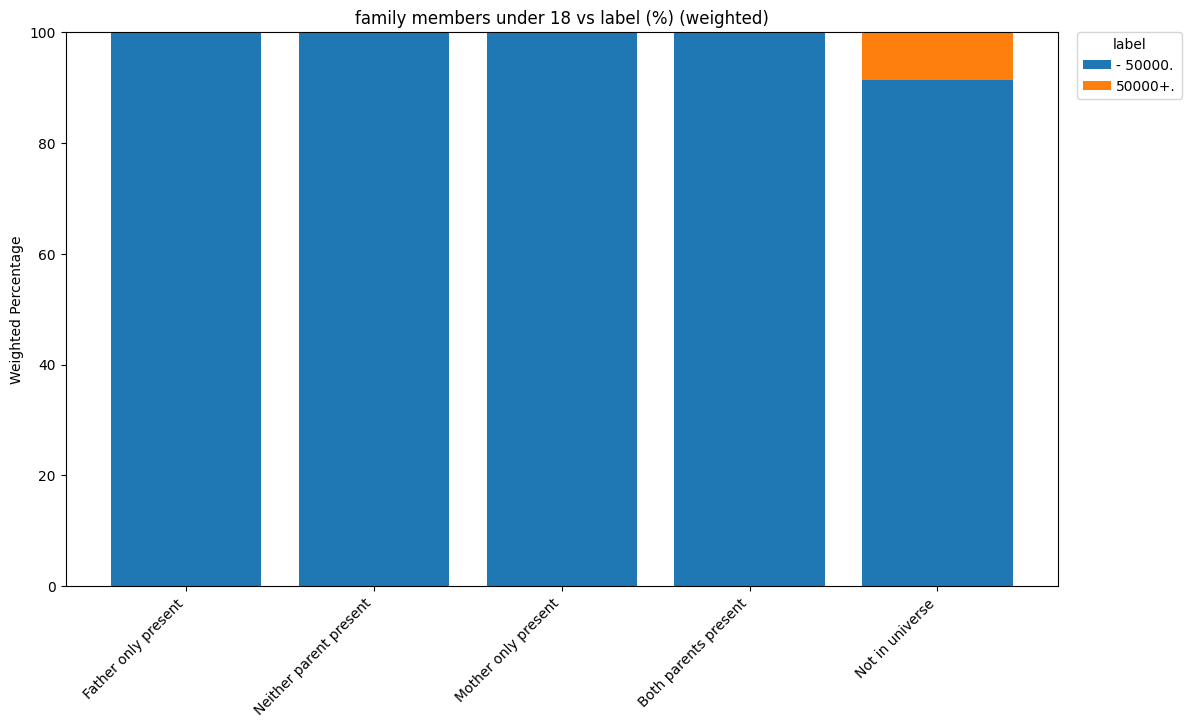

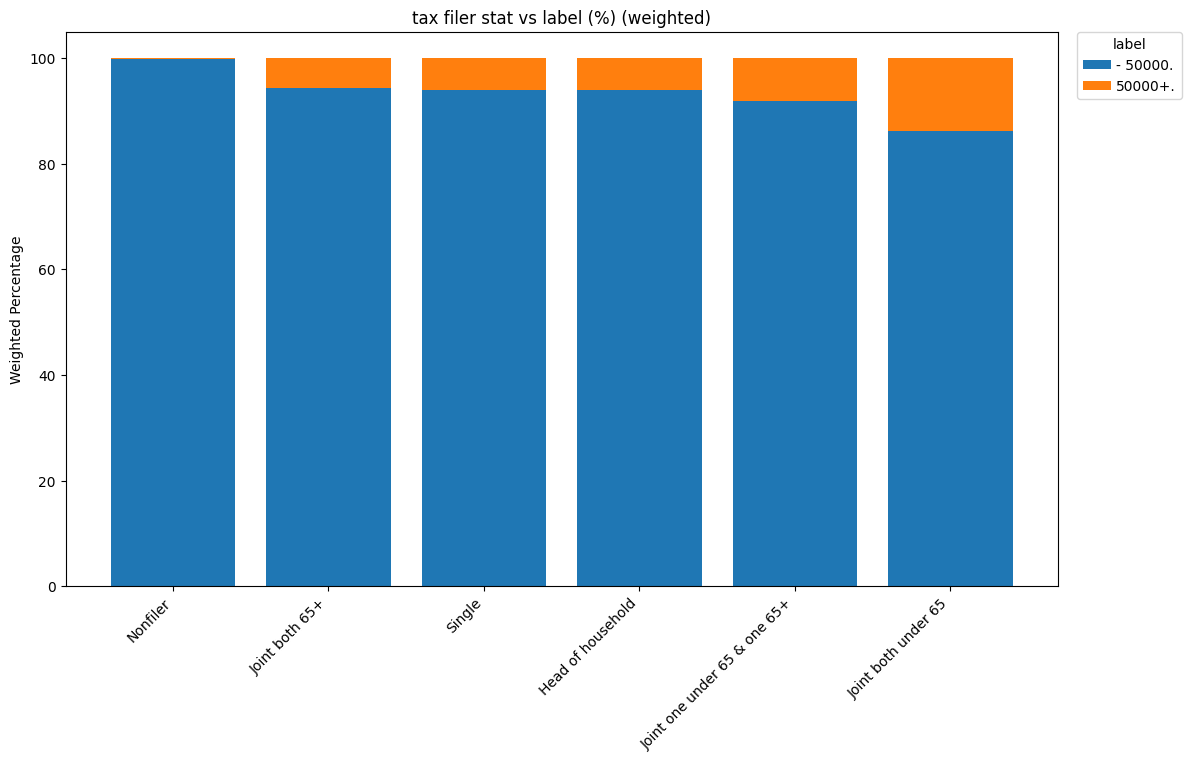

In [19]:
household_and_family_structure = [
    "marital stat",
    "detailed household and family stat",
    "detailed household summary in household",
    "family members under 18",
    "tax filer stat"
]

visualizations.plot_feature_group(
    raw_df,
    household_and_family_structure,
    numeric_categorical_columns=numeric_categorical_features,
    plot_kwargs=plot_kwargs
)

## Geography and Migration History

These track mobility and origin, often predictive of socioeconomic status.

Each of the following features contains both a Not in Universe category and a `?` category:

- `state of previous residence`
- `migration code-change in msa`
- `migration code-change in reg`
- `migration code-move within reg`
- `migration prev res in sunbelt`

The `?` category likely represents missing or unrecorded values. This distinction should be verified before use.

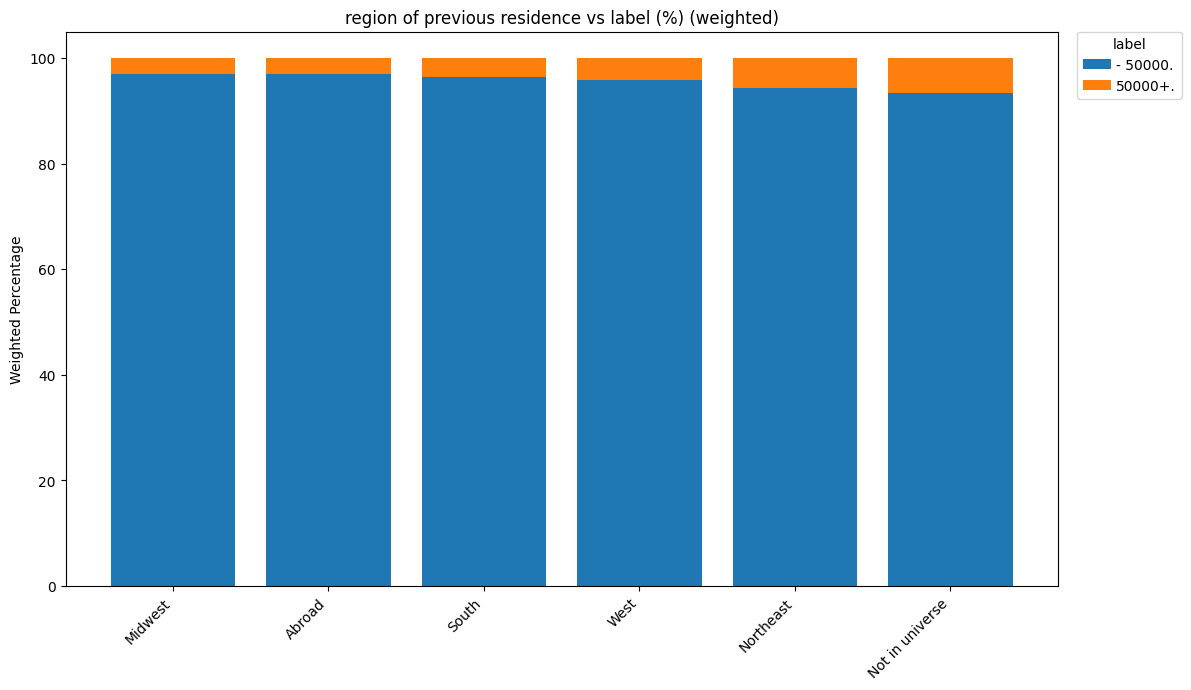

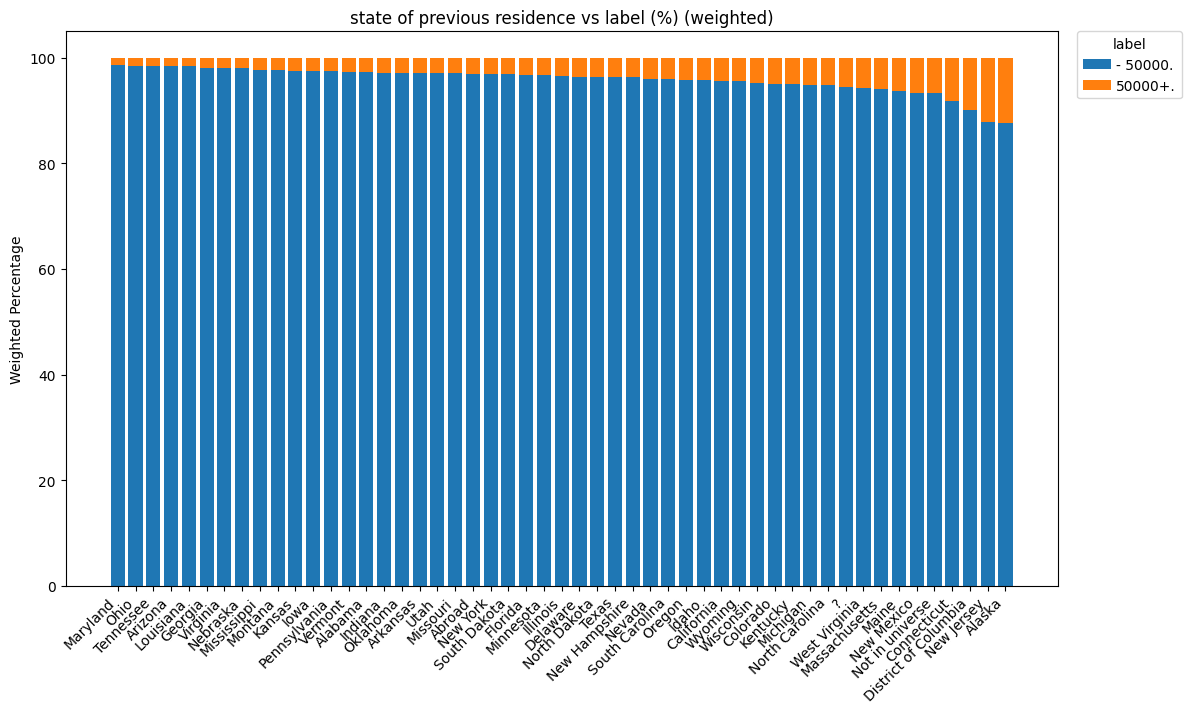

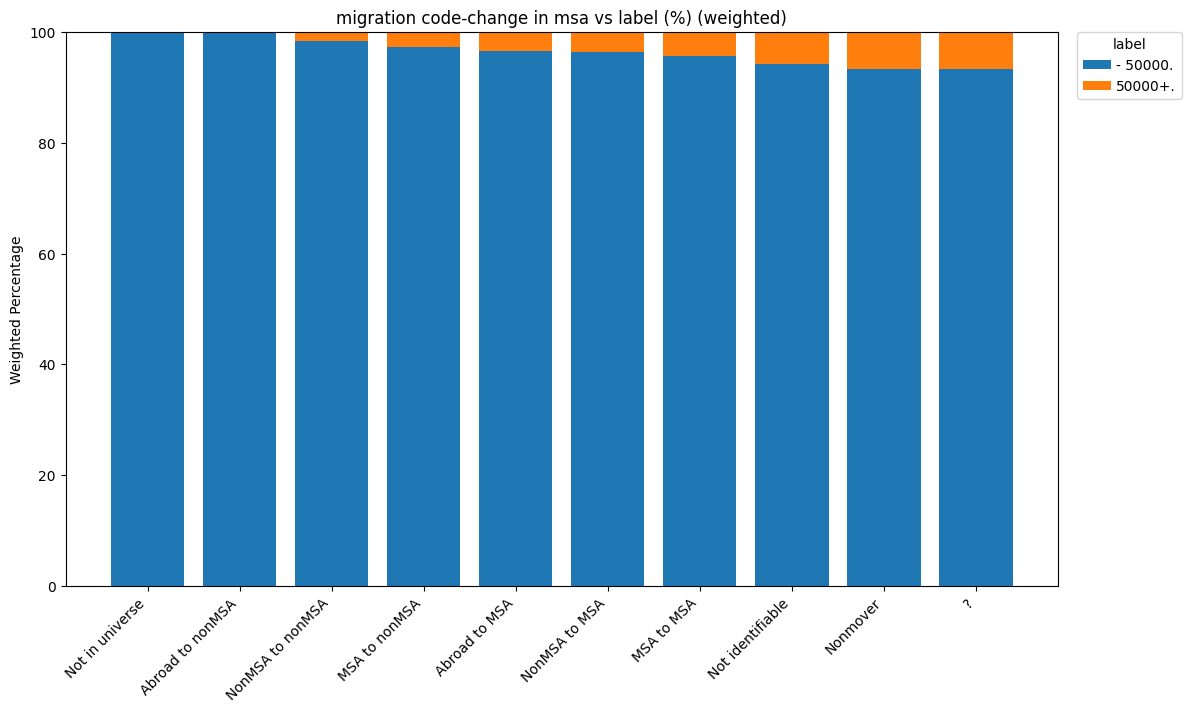

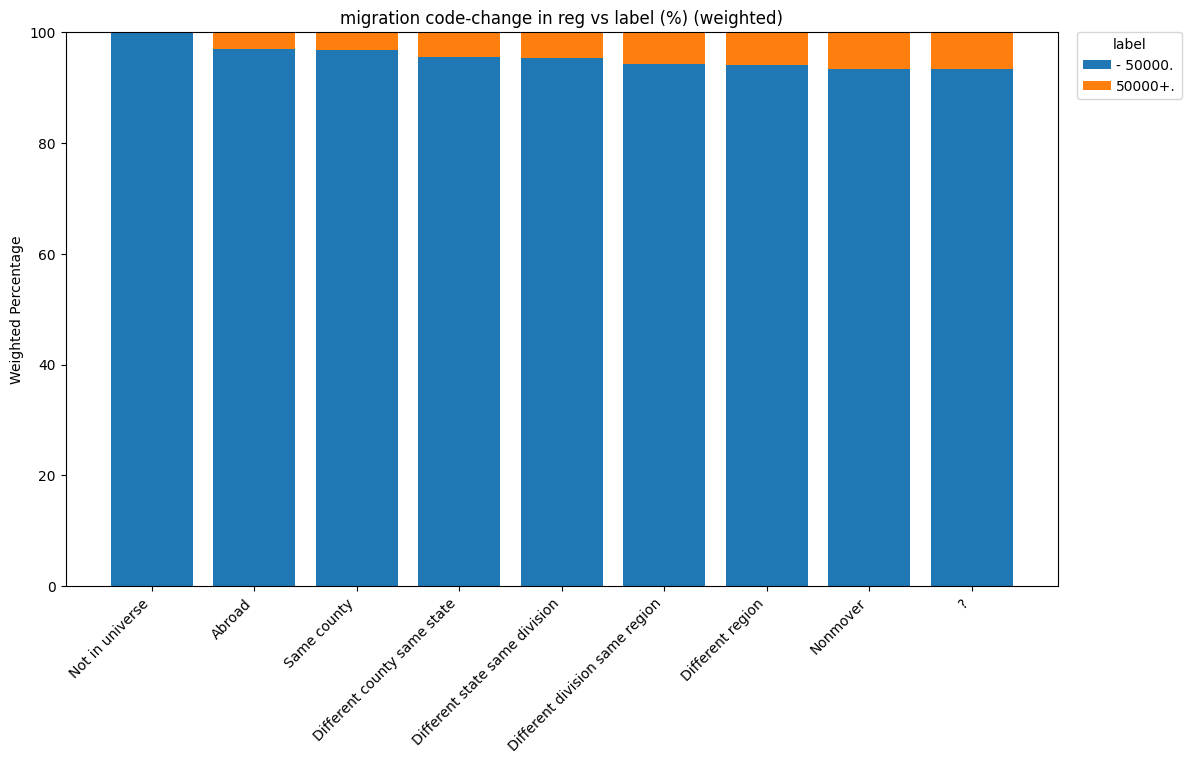

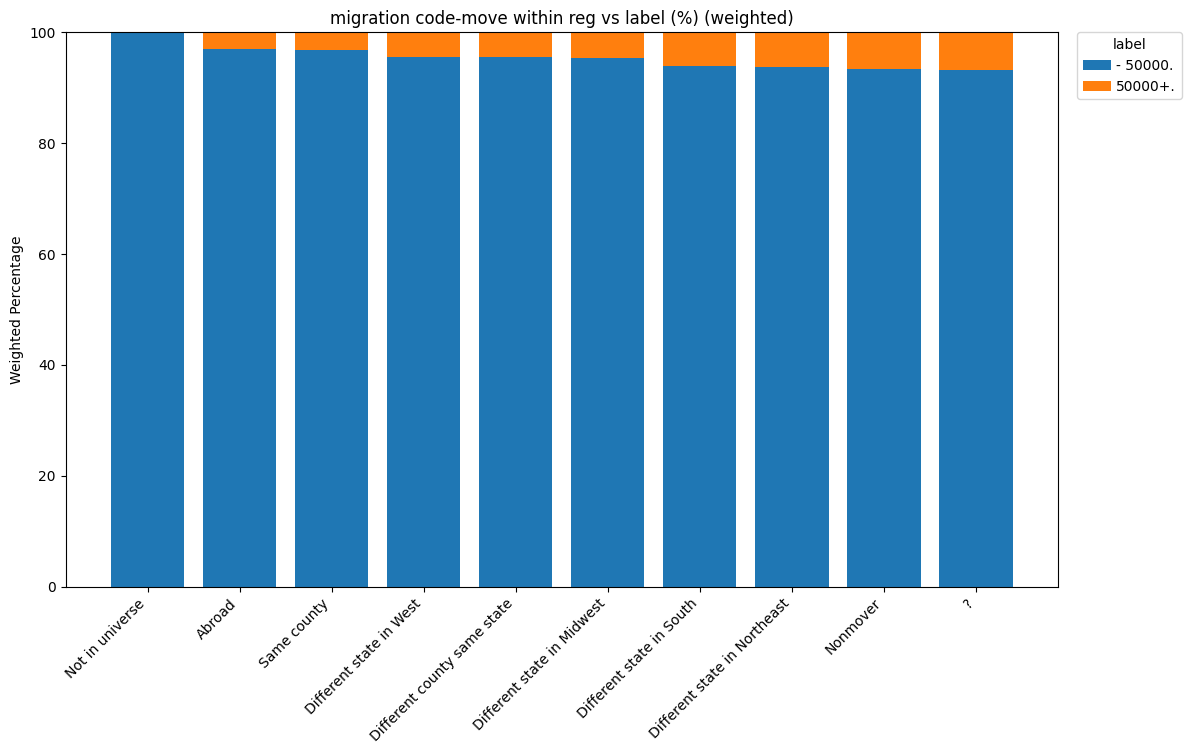

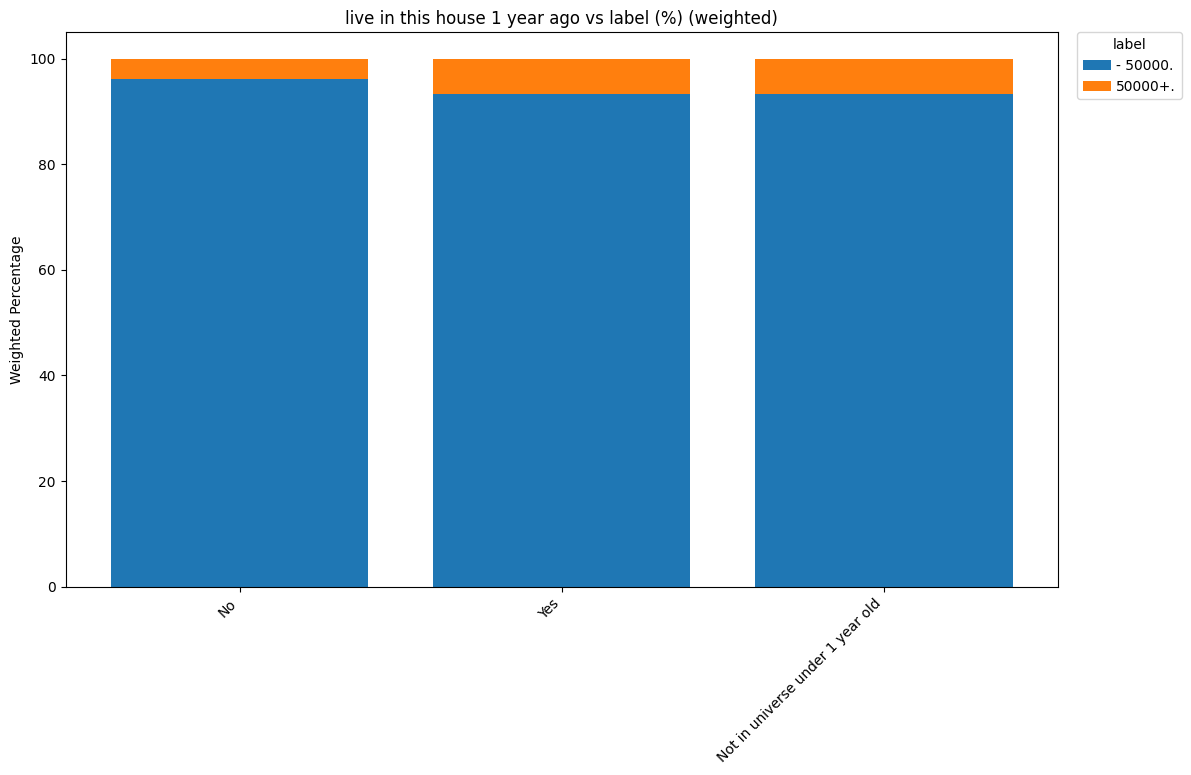

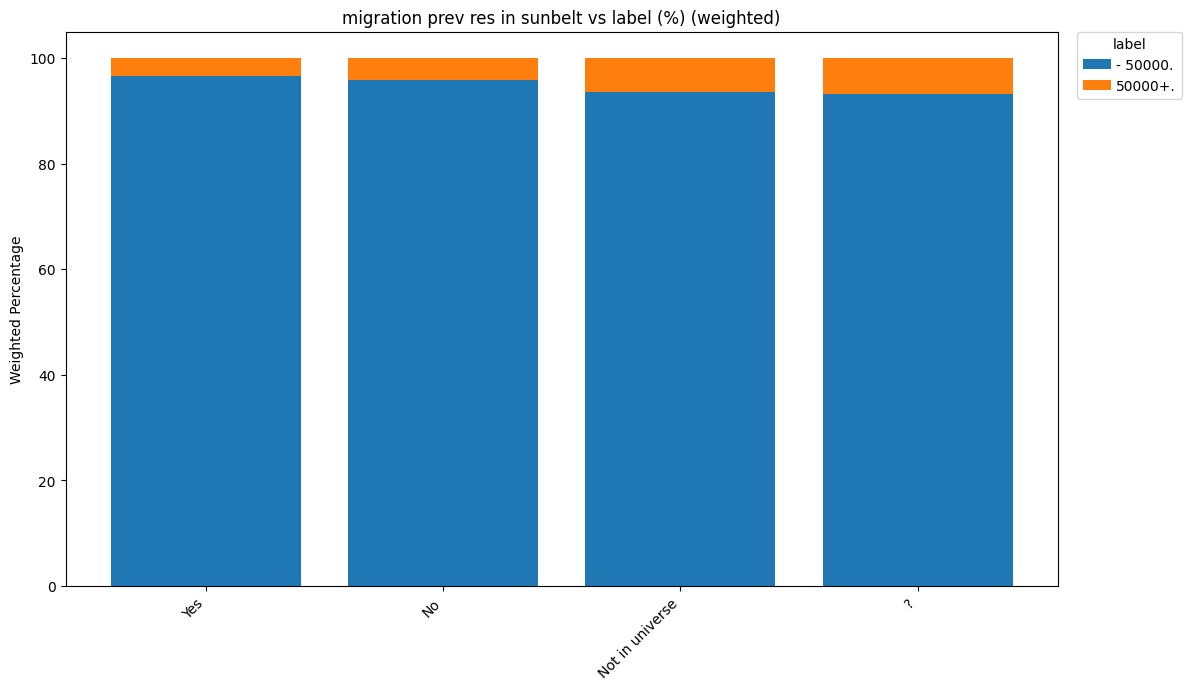

In [20]:
geography_and_migration_history = [
    "region of previous residence",
    "state of previous residence",
    "migration code-change in msa",
    "migration code-change in reg",
    "migration code-move within reg",
    "live in this house 1 year ago",
    "migration prev res in sunbelt"
]

visualizations.plot_feature_group(
    raw_df,
    geography_and_migration_history,
    numeric_categorical_columns=numeric_categorical_features,
    plot_kwargs=plot_kwargs
)

## Temporal Identifiers

Used for splitting or tracking data collection period. The `year` feature is probably not useful for modeling given the perfect split.

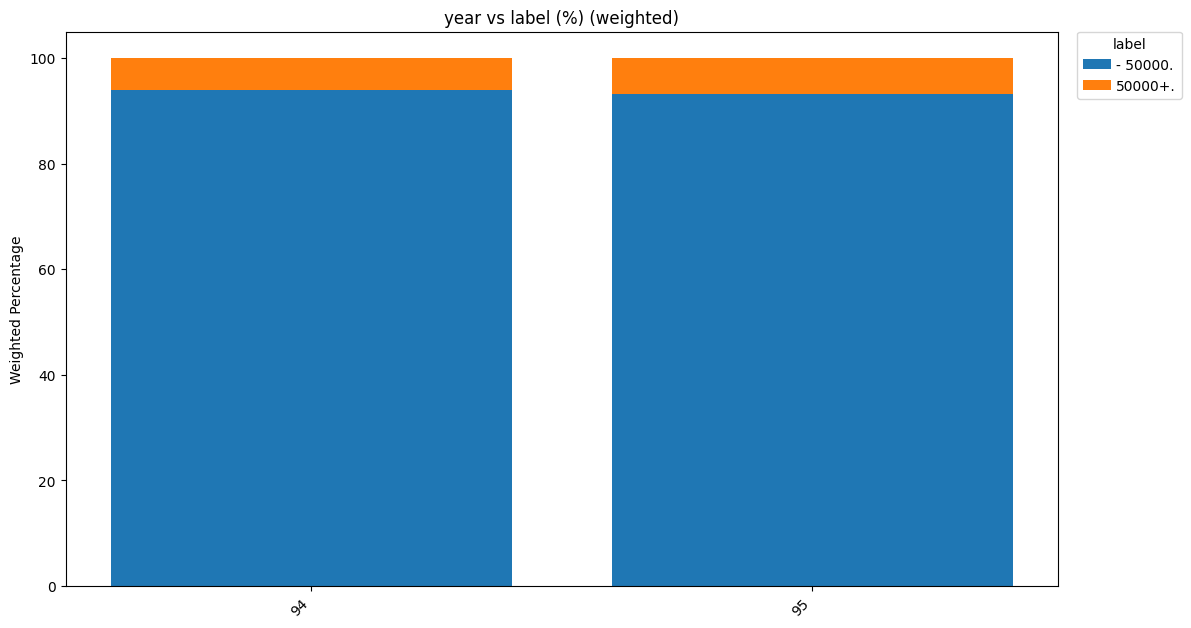

In [21]:
temporal_identifiers = [
    "year"
]

tmp_df = raw_df.copy()
tmp_df["year"] = tmp_df["year"].astype(str)
visualizations.plot_feature_group(
    tmp_df,
    temporal_identifiers,
    numeric_categorical_columns=["year"] + numeric_categorical_features,
    plot_kwargs=plot_kwargs,
)

## Survey Weights

This is the survey sampling weight.

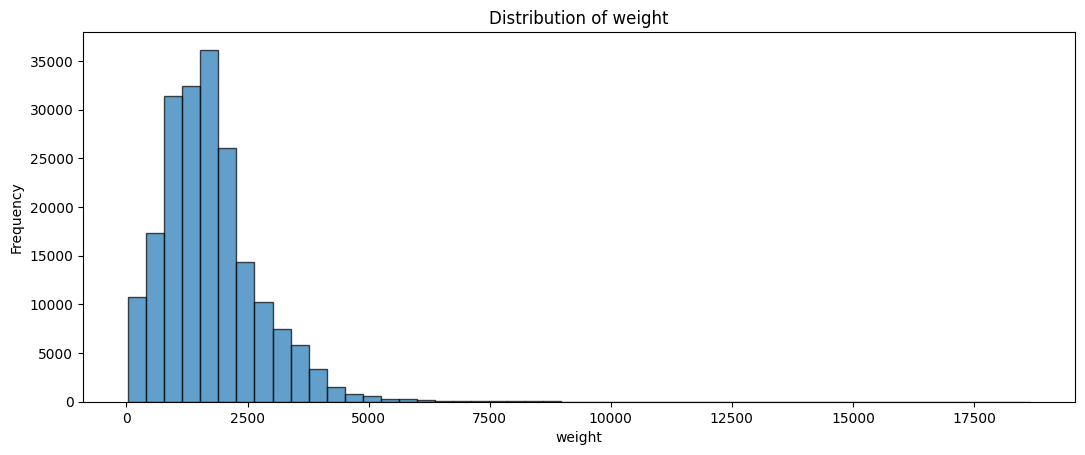

In [22]:
survey_weights = [
    weight_column
]

visualizations.plot_numeric_distribution(
    raw_df, column=weight_column, figsize=(2*6.4, 4.8)
)

## Target Variable

- `- 50000.`
- `50000+.`

There is a large class imbalance in the target variable.

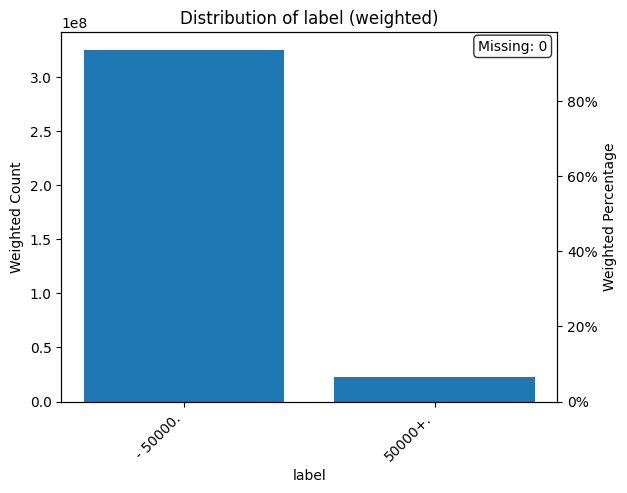

2026-06-18 00:52:05,471 - INFO - Saved DataFrame to results directory: /Users/jagraves21/notebooks/jpm/census-income-ml-project/data/Census/results/target_distribution.csv


In [23]:
target_variables = [
    target_column
]

visualizations.plot_categorical_distribution(
    raw_df,
    column=target_column,
    weight_column=weight_column,
    horizontal=False,
    figsize=(6.4, 4.8)
)

results_df = (
	raw_df
	.assign(**{
		"Weighted Count": raw_df[weight_column]
	})
	.groupby(target_column)
	.agg(
		Count=(target_column, "size"),
		Weighted_Count=("Weighted Count", "sum")
	)
	.rename_axis("Label")
	.reset_index()
	.assign(**{
		"Percentage (%)": lambda x: x["Count"] / x["Count"].sum() * 100,
		"Weighted Percentage (%)": lambda x: x["Weighted_Count"] / x["Weighted_Count"].sum() * 100
	})
	.rename(columns={
		"Weighted_Count": "Weighted Count"
	})
    [["Label", "Count", "Percentage (%)", "Weighted Count", "Weighted Percentage (%)"]]
)

_ = census.save_results_dataframe(results_df, "target_distribution.csv")

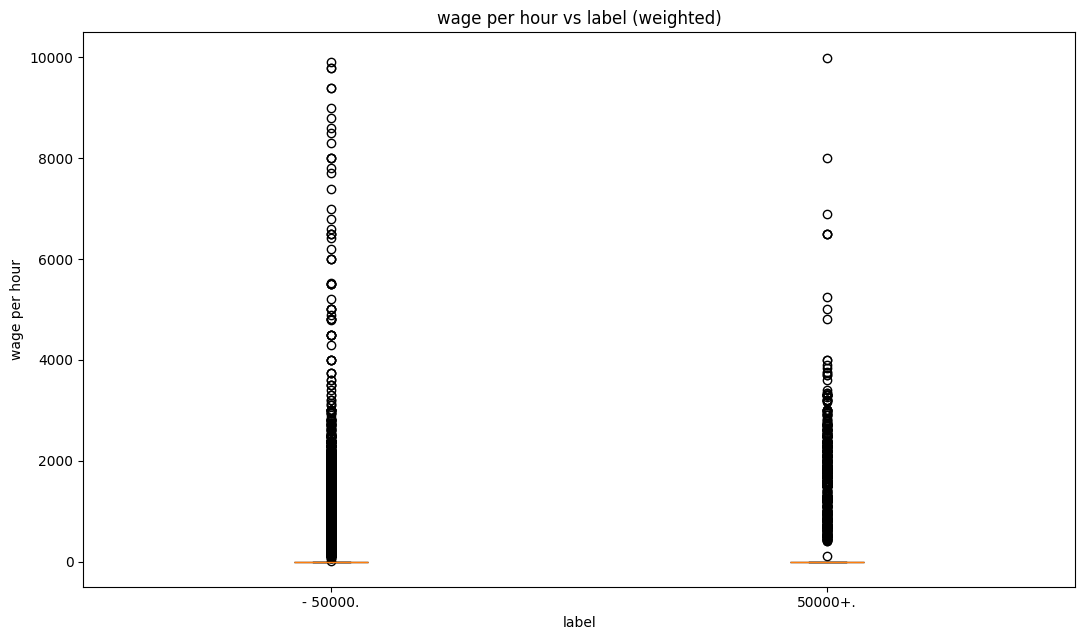

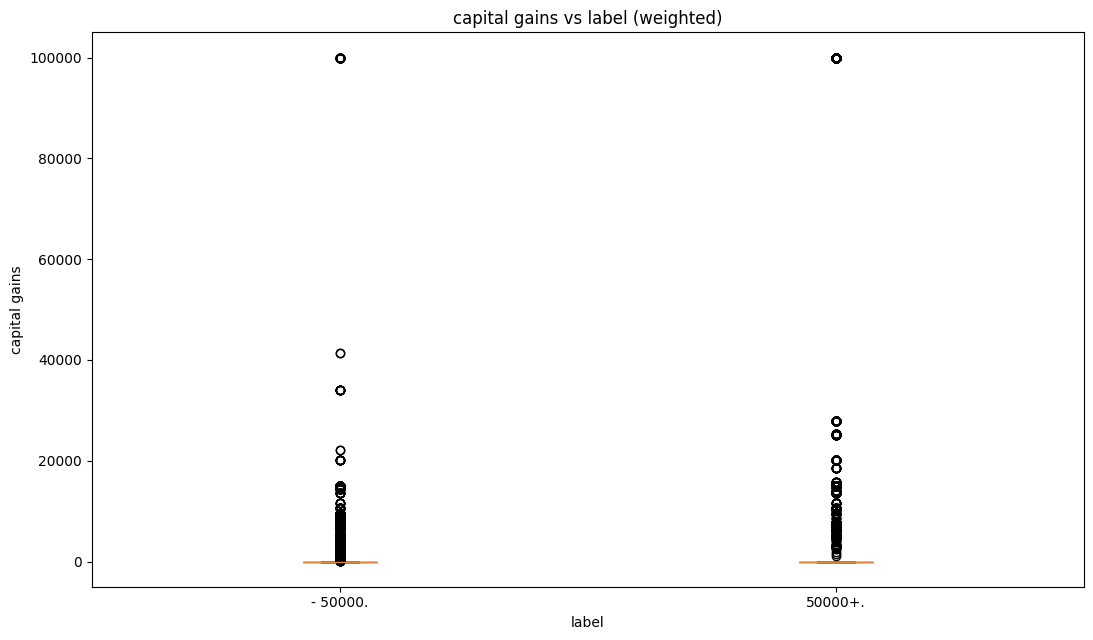

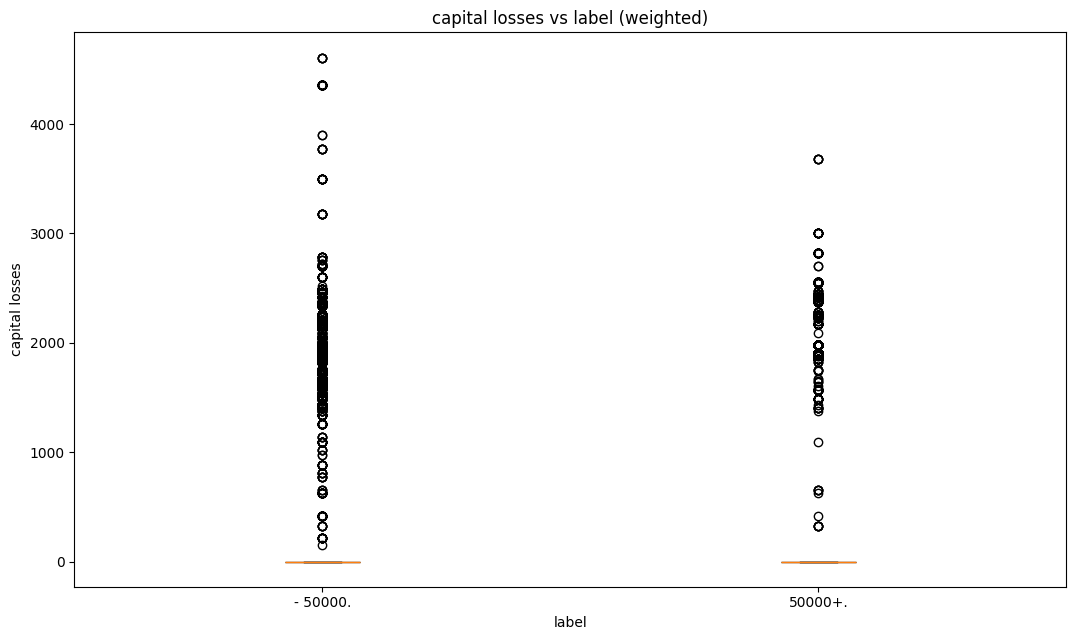

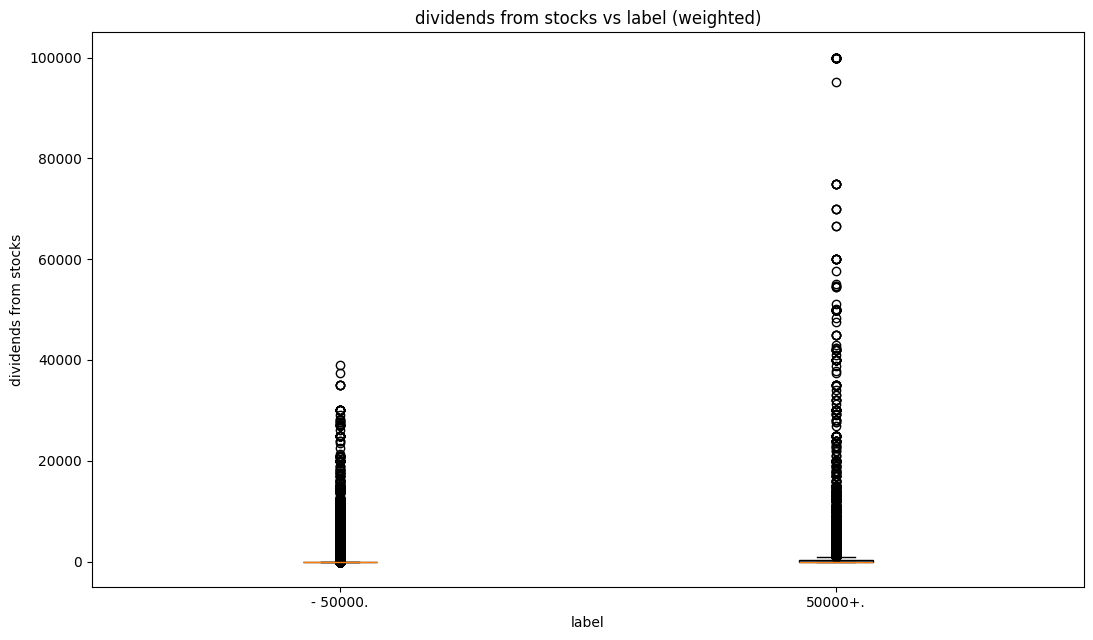

In [24]:
visualizations.plot_feature_group(
    raw_df,
    income_and_financial_indicators,
    numeric_categorical_columns=numeric_categorical_features,
    plot_kwargs=plot_kwargs
)

## Temporal Distribution Shifts

There appears to be a distribution shift between 1994 and 1995. While some variation is expected in census data over time, the presence of several large shifts is somewhat unexpected, particularly given the short time interval.

### Numeric Feature Distribution Shifts

The Kolmogorov–Smirnov test and Cohen's d were used to assess changes in the distributions and means of numeric features between 1994 and 1995. The results indicate that no substantial distribution shifts occurred across the numeric features.

In [25]:
def numeric_severity(d):
	d = abs(d)
	if d < 0.2:
		return "None"
	elif d < 0.5:
		return "Low"
	elif d < 0.8:
		return "Medium"
	else:
		return "Severe"
        
year_vals = sorted(raw_df["year"].dropna().unique())
df1 = raw_df[raw_df["year"] == year_vals[0]]
df2 = raw_df[raw_df["year"] == year_vals[1]]

def cohens_d(x, y):
	x = np.asarray(x)
	y = np.asarray(y)
	return (x.mean() - y.mean()) / np.sqrt((x.var(ddof=1) + y.var(ddof=1)) / 2)

results = []
for col in raw_df.columns:
	if col in categorical_columns or col == "year":
		continue

	if not pd.api.types.is_numeric_dtype(raw_df[col]):
		continue

	x = df1[col].dropna()
	y = df2[col].dropna()

	if len(x) < 2 or len(y) < 2:
		continue

	ks_stat, p = scipy.stats.ks_2samp(x, y)
	d = cohens_d(x, y)

	results.append({
		"Feature": col,
		"KS Statistic": ks_stat,
		"p-value": p,
		"Cohen's d": d,
		"Mean (Year 1)": x.mean(),
		"Mean (Year 2)": y.mean(),
		"Mean Shift": x.mean() - y.mean(),
        "Severity": numeric_severity(d)
	})

results_df = pd.DataFrame(results).sort_values(
	by="Cohen's d",
	key=lambda col: col.abs(),
	ascending=False
)

display(results_df.set_index("Feature"))
_ = census.save_results_dataframe(results_df, "numeric_distribution_shifts.csv")

,KS Statistic,p-value,Cohen's d,Mean (Year 1),Mean (Year 2),Mean Shift,Severity
Feature,,,,,,,
weight,0.020254,3.308332e-18,-0.023531,1728.696497,1752.079394,-23.382898,None
weeks worked in year,0.006393,3.374011e-02,-0.010504,23.046771,23.303192,-0.256421,None
capital gains,0.002739,8.474637e-01,-0.010487,410.104260,459.366063,-49.261802,None
veterans benefits,0.002705,8.577005e-01,-0.006245,1.512176,1.517493,-0.005317,None
wage per hour,0.002115,9.785710e-01,-0.004566,54.799774,56.054867,-1.255093,None
dividends from stocks,0.003062,7.367683e-01,-0.003825,193.736985,201.327064,-7.590079,None
capital losses,0.000626,1.000000e+00,-0.000191,37.287778,37.339833,-0.052055,None


2026-06-18 00:52:06,936 - INFO - Saved DataFrame to results directory: /Users/jagraves21/notebooks/jpm/census-income-ml-project/data/Census/results/numeric_distribution_shifts.csv


### Categorical Feature Distribution Shifts

Chi-square tests and Cramér's V were used to assess changes in categorical feature distributions between 1994 and 1995. Several features exhibit noticeable distributional shifts, particularly those related to geography and migration.

In [26]:
def categorical_severity(v):
	if v < 0.05:
		return "None"
	elif v < 0.10:
		return "Low"
	elif v < 0.20:
		return "Medium"
	elif v < 0.30:
		return "High"
	else:
		return "Severe"
        
results = []
for column in categorical_columns:
    table = pd.crosstab(raw_df[column], raw_df["year"])
    
    if table.shape[0] < 2 or table.shape[1] < 2:
        continue

    chi2, p, dof, _ = scipy.stats.chi2_contingency(table)

    n = table.to_numpy().sum()
    r, k = table.shape

    cramers_v = np.sqrt(chi2 / (n * (min(r - 1, k - 1))))

    results.append({
        "Feature": column,
        "Chi-Square": chi2,
        "p-value": p,
        "Degrees of Freedom": dof,
        "Cramér's V": cramers_v,
        "Number of Categories": r,
        "Severity": categorical_severity(cramers_v)
    })

results_df = pd.DataFrame(results).sort_values(
    by="Cramér's V",
    ascending=False
)

display(results_df.set_index("Feature"))
_ = census.save_results_dataframe(results_df, "categorical_distribution_shifts.csv")

,Chi-Square,p-value,Degrees of Freedom,Cramér's V,Number of Categories,Severity
Feature,,,,,,
migration prev res in sunbelt,199523.000000,0.000000e+00,3,1.000000,4,Severe
migration code-move within reg,199523.000000,0.000000e+00,9,1.000000,10,Severe
migration code-change in reg,199523.000000,0.000000e+00,8,1.000000,9,Severe
migration code-change in msa,199523.000000,0.000000e+00,9,1.000000,10,Severe
live in this house 1 year ago,193549.826813,0.000000e+00,2,0.984918,3,Severe
full or part time employment stat,122280.425064,0.000000e+00,7,0.782856,8,Severe
state of previous residence,17104.470555,0.000000e+00,50,0.292791,51,High
region of previous residence,17104.470555,0.000000e+00,5,0.292791,6,High
race,487.259152,3.815297e-104,4,0.049418,5,None


2026-06-18 00:52:08,159 - INFO - Saved DataFrame to results directory: /Users/jagraves21/notebooks/jpm/census-income-ml-project/data/Census/results/categorical_distribution_shifts.csv
